# V10: Multi-GNN — Optuna HPO · Balanced Threshold · 5-Fold CV · Feature Importance

**Fixes over V7:**
- **Reduced Grade-1 recall**: class-weight penalty softened to `sqrt(ratio)` ≈ 1.18; per-fold G-mean threshold optimisation replaces fixed 0.5
- **AUC fix**: explicit named-column construction (no brittle positional rename); `try/except` guard for single-class folds
- **5-Fold Stratified CV**: Optuna finds best params once per model×pipeline, then `StratifiedKFold(5)` evaluates generalisation — reports mean ± std across folds
- Final model trained on full train+val, threshold = mean(fold thresholds), evaluated on held-out TCGA test + external CGGA

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import random, copy, warnings

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             precision_score, recall_score, f1_score, accuracy_score)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold

from torch_geometric.data import HeteroData
from torch_geometric.nn import (GATv2Conv, Linear, HGTConv,
                                 RGCNConv, HypergraphConv, ChebConv)

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
from sdv.sampling import Condition
from imblearn.over_sampling import SMOTENC
from torch.optim.lr_scheduler import CosineAnnealingLR

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(42)

N_TRIALS   = 30    # Optuna TPE trials per model×pipeline
N_FOLDS    = 5     # stratified CV folds
MAX_EPOCHS = 200
PATIENCE   = 20

/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: libnvToolsExt.so.1: cannot open shared object file: No such file or directory
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "


Using device: cuda
GPU: NVIDIA GeForce RTX 3050


## 2. Load Data

In [2]:
tcga_df = pd.read_csv('../../dataset/TCGA_InfoWithGrade.csv')
cgga_df = pd.read_csv('../../dataset/weseq_processed_with_id_and_race_V2.csv')

if 'CGGA_ID' in cgga_df.columns:
    cgga_df = cgga_df.drop(columns='CGGA_ID')

categorical_columns = ['Grade', 'Gender', 'Race']
gene_columns = ['IDH1','TP53','ATRX','PTEN','EGFR','CIC','MUC16','PIK3CA',
                'NF1','PIK3R1','FUBP1','RB1','NOTCH1','BCOR','CSMD3',
                'SMARCA4','GRIN2A','IDH2','FAT4','PDGFRA']
NUM_GENES = len(gene_columns)

print("TCGA:", tcga_df.shape, "  Grade dist:", dict(tcga_df['Grade'].value_counts()))
print("CGGA:", cgga_df.shape, "  Grade dist:", dict(cgga_df['Grade'].value_counts()))

TCGA: (839, 24)   Grade dist: {0: 487, 1: 352}
CGGA: (286, 24)   Grade dist: {0: 184, 1: 102}


## 3. Splits — 20% held-out test; remaining 80% used for HPO + 5-Fold CV

In [3]:
# Hold out 20% as final test set (never seen during HPO or CV)
train_val_df, test_df = train_test_split(
    tcga_df, test_size=0.2, stratify=tcga_df['Grade'], random_state=42)

# Further split train_val for Optuna HPO warmup (val graph used only in HPO phase)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.2, stratify=train_val_df['Grade'], random_state=42)

print(f"Train(HPO)={len(train_df)}  Val(HPO)={len(val_df)}  "
      f"TrainVal(CV)={len(train_val_df)}  Test={len(test_df)}")
print("Train Grade dist:", dict(train_df['Grade'].value_counts()))
print("Test  Grade dist:", dict(test_df['Grade'].value_counts()))

Train(HPO)=536  Val(HPO)=135  TrainVal(CV)=671  Test=168
Train Grade dist: {0: 311, 1: 225}
Test  Grade dist: {0: 98, 1: 70}


## 4. Graph Construction

In [4]:
_PP_CACHE: dict = {}


def construct_bipartite_heterograph(df: pd.DataFrame) -> HeteroData:
    graph = HeteroData()
    scaler    = StandardScaler()
    age_norm  = scaler.fit_transform(df[['Age_at_diagnosis']])
    pat_feats = np.hstack([df[['Gender','Race']].values, age_norm])
    graph['Patient'].x = torch.tensor(pat_feats, dtype=torch.float)
    graph['Patient'].y = torch.tensor(df['Grade'].values, dtype=torch.long)
    graph['Gene'].x    = torch.eye(NUM_GENES, dtype=torch.float)

    src_genes, dst_patients = [], []
    for p_idx, (_, row) in enumerate(df.iterrows()):
        for g_idx, gene in enumerate(gene_columns):
            if int(row[gene]) == 1:
                src_genes.append(g_idx); dst_patients.append(p_idx)

    graph['Gene',    'mutates',    'Patient'].edge_index = torch.tensor([src_genes,    dst_patients], dtype=torch.long)
    graph['Patient', 'mutated_by', 'Gene'   ].edge_index = torch.tensor([dst_patients, src_genes   ], dtype=torch.long)
    return graph


def get_pp_edges(graph: HeteroData, max_pts: int = 30):
    key = id(graph)
    if key in _PP_CACHE:
        return _PP_CACHE[key]
    ei = graph[('Gene','mutates','Patient')].edge_index.cpu()
    gene_ids, pat_ids = ei[0], ei[1]
    n_p = graph['Patient'].x.shape[0]
    all_src, all_dst, all_types = [], [], []
    torch.manual_seed(42)
    for g in range(NUM_GENES):
        mask = (gene_ids == g)
        pts = pat_ids[mask].unique(); n = len(pts)
        if n < 2: continue
        if n > max_pts:
            pts = pts[torch.randperm(n)[:max_pts]]; n = max_pts
        src = pts.repeat_interleave(n); dst = pts.repeat(n)
        valid = (src != dst)
        all_src.append(src[valid]); all_dst.append(dst[valid])
        all_types.append(torch.full((valid.sum(),), g, dtype=torch.long))
    if all_src:
        pp_ei = torch.stack([torch.cat(all_src), torch.cat(all_dst)])
        pp_et = torch.cat(all_types)
    else:
        idx = torch.arange(n_p)
        pp_ei = torch.stack([idx, idx]); pp_et = torch.zeros(n_p, dtype=torch.long)
    _PP_CACHE[key] = (pp_ei, pp_et)
    return pp_ei, pp_et


def to_dev(graph): return graph.to(device)


def clear_pp_cache():
    """Call between CV folds to free stale graph-id entries."""
    _PP_CACHE.clear()

## 5. Build Shared Evaluation Graphs

In [5]:
val_graph  = to_dev(construct_bipartite_heterograph(val_df))
test_graph = to_dev(construct_bipartite_heterograph(test_df))
cgga_graph = to_dev(construct_bipartite_heterograph(cgga_df))

print("Val  graph:", val_graph['Patient'].x.shape[0], "patients")
print("Test graph:", test_graph['Patient'].x.shape[0], "patients")
print("CGGA graph:", cgga_graph['Patient'].x.shape[0], "patients")

Val  graph: 135 patients
Test graph: 168 patients
CGGA graph: 286 patients


## 6. Model Definitions (7 architectures)

| # | Model | Core idea |
|---|-------|-----------|
| 1 | **HeteroGATv2** | Bidirectional GATv2 on Gene-Patient bipartite graph |
| 2 | **MOGAT** | Dual genomic+clinical paths, soft fusion gate |
| 3 | **HyperTMO** | Genes = hyperedges, patients = nodes |
| 4 | **RGCN** | Patient-patient co-mutation graph, 20 gene-typed relations |
| 5 | **VEGN** | Learned per-edge variant-effect weights |
| 6 | **FastHGTConv** | Heterogeneous Graph Transformer |
| 7 | **SGNN** | Chebyshev spectral filters on patient co-mutation adjacency |

In [6]:
# ── 1. HeteroGATv2 ───────────────────────────────────────────
class HeteroGATv2(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.g2p = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.p2g = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.p_skip = Linear(hidden_dim, hidden_dim); self.g_skip = Linear(hidden_dim, hidden_dim)
        self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        hp = self.p_skip(hp) + self.g2p((hg, hp), ei[('Gene','mutates','Patient')])
        hg = self.g_skip(hg) + self.p2g((hp, hg), ei[('Patient','mutated_by','Gene')])
        return self.clf(F.dropout(F.leaky_relu(hp, 0.2), self.dr, training=self.training))

    def get_attn_weights(self, graph):
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        _, (eidx, alpha) = self.g2p((hg, hp), ei[('Gene','mutates','Patient')],
                                     return_attention_weights=True)
        return eidx, alpha.detach().mean(dim=-1)


# ── 2. MOGAT ──────────────────────────────────────────────────────
class MOGAT(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.pg = Linear(-1, hidden_dim); self.gg = Linear(-1, hidden_dim)
        self.gat = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.pc = Linear(-1, hidden_dim)
        self.mlp = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim))
        self.gate = nn.Linear(hidden_dim * 2, 2); self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        e = graph[('Gene','mutates','Patient')].edge_index
        hpg = F.relu(self.pg(graph['Patient'].x)); hgg = F.relu(self.gg(graph['Gene'].x))
        hpg = F.dropout(F.leaky_relu(self.gat((hgg, hpg), e), 0.2), self.dr, training=self.training)
        hpc = self.mlp(F.relu(self.pc(graph['Patient'].x)))
        g   = torch.softmax(self.gate(torch.cat([hpg, hpc], -1)), dim=-1)
        return self.clf(g[:, :1] * hpg + g[:, 1:] * hpc)


# ── 3. HyperTMO ───────────────────────────────────────────────────
class HyperTMO(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, in_channels=3, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = nn.Linear(in_channels, hidden_dim)
        self.g_lin = nn.Linear(NUM_GENES, hidden_dim)        # projects hyperedge attrs
        self.hc1 = HypergraphConv(hidden_dim, hidden_dim, use_attention=True,
                                   heads=num_heads, dropout=dropout, concat=False)
        self.hc2 = HypergraphConv(hidden_dim, hidden_dim)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x; xg = graph['Gene'].x
        ei = graph[('Gene','mutates','Patient')].edge_index
        hei = torch.stack([ei[1], ei[0]], dim=0)   # [patient, gene]
        hp = F.relu(self.p_lin(xp)); hg = F.relu(self.g_lin(xg)); s = self.skip(hp)
        hp = F.relu(self.hc1(hp, hei, hyperedge_attr=hg))
        hp = F.dropout(hp, self.dr, training=self.training)
        hp = self.bn(F.relu(self.hc2(hp, hei) + s))
        return self.clf(F.dropout(hp, self.dr, training=self.training))


# ── 4. RGCN ───────────────────────────────────────────────────────
class RGCNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 in_channels=3, num_relations=20, **_):
        super().__init__()
        self.dr = dropout
        self.lin = nn.Linear(in_channels, hidden_dim)
        self.rc1 = RGCNConv(hidden_dim, hidden_dim, num_relations=num_relations)
        self.rc2 = RGCNConv(hidden_dim, hidden_dim, num_relations=num_relations)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x
        pp_ei, pp_et = get_pp_edges(graph)
        pp_ei = pp_ei.to(xp.device); pp_et = pp_et.to(xp.device)
        h = F.relu(self.lin(xp)); s = self.skip(h)
        h = F.relu(self.rc1(h, pp_ei, pp_et))
        h = F.dropout(h, self.dr, training=self.training)
        h = self.bn(F.relu(self.rc2(h, pp_ei, pp_et) + s))
        return self.clf(F.dropout(h, self.dr, training=self.training))


# ── 5. VEGN ───────────────────────────────────────────────────────
class VEGNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.ve = nn.Sequential(nn.Linear(hidden_dim*2, hidden_dim), nn.ReLU(),
                                 nn.Linear(hidden_dim, 1), nn.Sigmoid())
        self.p2g = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.skip = Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x; xg = graph['Gene'].x
        e_g2p = graph[('Gene','mutates','Patient')].edge_index
        e_p2g = graph[('Patient','mutated_by','Gene')].edge_index
        hp = F.relu(self.p_lin(xp)); hg = F.relu(self.g_lin(xg))
        sg, dp = e_g2p[0], e_g2p[1]
        wt = self.ve(torch.cat([hg[sg], hp[dp]], -1)).squeeze(-1)
        msg = hg[sg] * wt.unsqueeze(-1)
        agg = torch.zeros_like(hp); agg.scatter_add_(0, dp.unsqueeze(-1).expand_as(msg), msg)
        deg = torch.zeros(hp.shape[0], device=hp.device)
        deg.scatter_add_(0, dp, wt); deg = deg.clamp(min=1)
        agg = agg / deg.unsqueeze(-1)
        _ = self.p2g((hp, hg), e_p2g)
        hp2 = self.bn(F.leaky_relu(self.skip(hp) + agg, 0.2))
        return self.clf(F.dropout(hp2, self.dr, training=self.training))


# ── 6. FastHGTConv ────────────────────────────────────────────────
_HGT_META = (['Patient','Gene'],
              [('Gene','mutates','Patient'),('Patient','mutated_by','Gene')])

class FastHGTModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.hgt1 = HGTConv(hidden_dim, hidden_dim, metadata=_HGT_META, heads=num_heads)
        self.hgt2 = HGTConv(hidden_dim, hidden_dim, metadata=_HGT_META, heads=num_heads)
        self.skip = Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xd = {'Patient': F.relu(self.p_lin(graph['Patient'].x)),
              'Gene':    F.relu(self.g_lin(graph['Gene'].x))}
        sp = self.skip(xd['Patient']); ei = graph.edge_index_dict
        xd = {k: F.dropout(F.relu(v), self.dr, training=self.training)
              for k, v in self.hgt1(xd, ei).items()}
        xd = self.hgt2(xd, ei)
        hp = self.bn(F.relu(xd['Patient'] + sp))
        return self.clf(F.dropout(hp, self.dr, training=self.training))


# ── 7. SGNN ───────────────────────────────────────────────────────
class SGNNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 in_channels=3, K=3, **_):
        super().__init__()
        self.dr = dropout
        self.lin = nn.Linear(in_channels, hidden_dim)
        self.c1 = ChebConv(hidden_dim, hidden_dim, K=K)
        self.c2 = ChebConv(hidden_dim, hidden_dim, K=K)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim); self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x
        pp_ei, _ = get_pp_edges(graph); pp_ei = pp_ei.to(xp.device)
        h = F.relu(self.lin(xp)); s = self.skip(h)
        h = self.bn1(F.relu(self.c1(h, pp_ei)))
        h = F.dropout(h, self.dr, training=self.training)
        h = self.bn2(F.relu(self.c2(h, pp_ei) + s))
        return self.clf(F.dropout(h, self.dr, training=self.training))


# ── Registry ──────────────────────────────────────────────────────
MODEL_REGISTRY = [
    ('HeteroGATv2', HeteroGATv2,  {}),
    ('MOGAT',       MOGAT,        {}),
    ('HyperTMO',    HyperTMO,     {'in_channels': 3}),
    ('RGCN',        RGCNModel,    {'in_channels': 3, 'num_relations': NUM_GENES}),
    ('VEGN',        VEGNModel,    {}),
    ('FastHGTConv', FastHGTModel, {}),
    ('SGNN',        SGNNModel,    {'in_channels': 3}),
]
print(f"Registered {len(MODEL_REGISTRY)} models:", [n for n,_,_ in MODEL_REGISTRY])

Registered 7 models: ['HeteroGATv2', 'MOGAT', 'HyperTMO', 'RGCN', 'VEGN', 'FastHGTConv', 'SGNN']


## 7. Focal Loss + Softened Class Weights

**Fix**: penalty changed from `ratio` (≈1.38) to `sqrt(ratio)` (≈1.18).  
The FocalLoss `gamma=2` already down-weights easy examples; stacking a high class penalty over-corrects and inflates Grade-1 recall. Softening to square-root keeps a mild correction without making the decision boundary too aggressive toward Grade-1.

In [7]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, weight=None):
        super().__init__()
        self.a, self.g, self.w = alpha, gamma, weight
    def forward(self, inp, tgt):
        ce = F.cross_entropy(inp, tgt, weight=self.w, reduction='none')
        return (self.a * (1 - torch.exp(-ce)) ** self.g * ce).mean()

counts  = train_df['Grade'].value_counts()
# ── FIX: soften penalty from ratio → sqrt(ratio) ─────────────────
penalty = float(np.sqrt(counts.max() / counts.min()))   # was counts.max()/counts.min()
cw      = torch.tensor([1.0, penalty], dtype=torch.float).to(device)
criterion = FocalLoss(alpha=1, gamma=2, weight=cw)
print(f"Class weights: [1.0, {penalty:.4f}]  (sqrt-penalty; was {counts.max()/counts.min():.4f})")

Class weights: [1.0, 1.1757]  (sqrt-penalty; was 1.3822)


## 8. Threshold Optimisation + Evaluation Helpers

**Fix**: `find_optimal_threshold()` searches `[0.30, 0.75]` for the threshold maximising **G-mean = √(recall₀ × recall₁)**. G-mean is maximised when both recalls are balanced, so Grade-1 recall can no longer climb arbitrarily high at Grade-0's expense.

**AUC fix**: `compute_metrics()` uses explicit `try/except` around `roc_auc_score` and returns `nan` for degenerate folds rather than crashing.

In [8]:
# ── FIX: G-mean threshold search ─────────────────────────────────
def find_optimal_threshold(probs: np.ndarray, labels: np.ndarray,
                            low: float = 0.30, high: float = 0.75,
                            step: float = 0.01) -> float:
    """Return the decision threshold in [low, high] that maximises
    G-mean = sqrt(sensitivity_0 * sensitivity_1).
    Falls back to 0.5 if no positive G-mean is found."""
    best_th, best_gm = 0.5, -1.0
    for th in np.arange(low, high + step * 0.5, step):
        preds = (probs >= th).astype(int)
        r1 = recall_score(labels, preds, pos_label=1, zero_division=0)
        r0 = recall_score(labels, preds, pos_label=0, zero_division=0)
        gm = np.sqrt(r0 * r1)
        if gm > best_gm:
            best_gm = gm; best_th = float(th)
    return best_th


def evaluate_model(model, graph, threshold: float = 0.5):
    """Return (preds, probs, labels) using a calibrated threshold."""
    model.eval()
    with torch.no_grad():
        logits = model(graph)
        probs  = F.softmax(logits, 1)[:, 1].cpu().numpy()
        labels = graph['Patient'].y.cpu().numpy()
    preds = (probs >= threshold).astype(int)
    return preds, probs, labels


def compute_metrics(preds: np.ndarray, probs: np.ndarray,
                     labels: np.ndarray) -> dict:
    """AUC fix: explicit try/except; also report per-class recall."""
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = float('nan')   # single-class fold guard
    return {
        'auc':       auc,
        'accuracy':  accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall':    recall_score(labels, preds, zero_division=0),       # Grade-1 recall
        'recall_0':  recall_score(labels, preds, pos_label=0, zero_division=0),
        'f1':        f1_score(labels, preds, zero_division=0),
    }


# Storage containers
all_results  = []    # final test/CGGA results
cv_results   = []    # per-fold CV results
all_models   = {}    # {(model_name, pipeline): trained model}
all_studies  = {}    # {(model_name, pipeline): optuna study}
all_params   = {}    # {(model_name, pipeline): best_params}
all_thresholds = {}  # {(model_name, pipeline): threshold}
PIPELINES    = ['No Balancing', 'SMOTE', 'CTGAN']

## 9. Unified Training Function

In [9]:
def train_and_evaluate(train_graph, val_graph, params, ModelClass,
                        fixed_kw=None, max_epochs=MAX_EPOCHS, patience=PATIENCE):
    """Train model; return (best_val_auc, best_state, history)."""
    kw = {'hidden_dim': params['hidden_dim'], 'out_dim': 2,
          'num_heads':  params['num_heads'],  'dropout': params['dropout']}
    if fixed_kw: kw.update(fixed_kw)

    model = ModelClass(**kw).to(device)
    try:
        with torch.no_grad(): _ = model(train_graph)
    except Exception: pass

    opt = torch.optim.AdamW(model.parameters(),
                              lr=params['lr'], weight_decay=params['weight_decay'])
    sch = CosineAnnealingLR(opt, T_max=max_epochs, eta_min=params['lr'] * 0.05)

    best_auc, ctr, best_state, history = 0.0, 0, None, []
    for _ in range(max_epochs):
        model.train(); opt.zero_grad()
        loss = criterion(model(train_graph), train_graph['Patient'].y)
        loss.backward(); opt.step(); sch.step()

        model.eval()
        with torch.no_grad():
            vp  = F.softmax(model(val_graph), 1)[:, 1].cpu().numpy()
            vl  = val_graph['Patient'].y.cpu().numpy()
        try:
            auc = roc_auc_score(vl, vp)
        except ValueError:
            auc = 0.0
        history.append(auc)

        if auc > best_auc:
            best_auc, ctr = auc, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            ctr += 1
            if ctr >= patience: break

    return best_auc, best_state, history

## 10. Optuna HPO (warm-up on train_df / val_df)

In [10]:
def run_optuna(train_graph, val_graph, ModelClass, fixed_kw=None,
               n_trials=N_TRIALS, label=''):
    """Bayesian HPO; return (best_params, best_state, study)."""

    def objective(trial):
        params = {
            'hidden_dim':   trial.suggest_categorical('hidden_dim', [16, 32, 64, 128]),
            'num_heads':    trial.suggest_categorical('num_heads',  [2, 4, 8]),
            'dropout':      trial.suggest_float('dropout', 0.05, 0.30, step=0.05),
            'lr':           trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True),
        }
        auc, _, _ = train_and_evaluate(train_graph, val_graph, params, ModelClass, fixed_kw)
        return auc

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    bp = study.best_params
    print(f"  [{label}] Best AUC={study.best_value:.4f}  params={bp}")
    _, best_state, _ = train_and_evaluate(train_graph, val_graph, bp, ModelClass, fixed_kw)
    return bp, best_state, study

## 11. 5-Fold Stratified Cross-Validation

Uses the **fixed best params** found by Optuna.  Each fold: augment training portion → build graph → train → find G-mean threshold on val → evaluate.  
Reports mean ± std across folds for AUC, Accuracy, Precision, Recall (Grade-1 & Grade-0), F1, Threshold.

In [11]:
def apply_smote(fold_train_df):
    feat_cols = gene_columns + ['Gender','Race','Age_at_diagnosis']
    cat_idx   = [i for i,c in enumerate(feat_cols)
                  if c in gene_columns or c in ['Gender','Race']]
    sm = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=3)
    Xr, yr = sm.fit_resample(fold_train_df[feat_cols], fold_train_df['Grade'])
    df2 = pd.DataFrame(Xr, columns=feat_cols); df2['Grade'] = yr
    for c in gene_columns: df2[c] = df2[c].round().astype(int)
    return df2


def apply_ctgan(fold_train_df):
    meta = SingleTableMetadata()
    meta.detect_from_dataframe(fold_train_df)
    for col in categorical_columns + gene_columns:
        meta.update_column(column_name=col, sdtype='categorical')
    vc    = fold_train_df['Grade'].value_counts()
    n_gen = int(vc.max() - vc.min())
    if n_gen <= 0:
        return fold_train_df
    syn = CTGANSynthesizer(meta, epochs=100, batch_size=50, verbose=False, cuda=True)
    syn.fit(fold_train_df)
    cond  = Condition(num_rows=n_gen, column_values={'Grade': int(vc.idxmin())})
    extra = syn.sample_from_conditions(conditions=[cond])
    return pd.concat([fold_train_df, extra], ignore_index=True)


def run_5fold_cv(train_val_df, best_params, ModelClass, fixed_kw,
                  pipeline_name, model_name):
    """Run StratifiedKFold(5) with fixed best_params.
    Returns DataFrame of per-fold metrics."""
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_records = []

    for fold, (tr_idx, vl_idx) in enumerate(
            skf.split(train_val_df, train_val_df['Grade']), start=1):
        fold_tr = train_val_df.iloc[tr_idx].copy().reset_index(drop=True)
        fold_vl = train_val_df.iloc[vl_idx].copy().reset_index(drop=True)

        # Apply augmentation to training portion only
        if pipeline_name == 'SMOTE':
            fold_tr = apply_smote(fold_tr)
        elif pipeline_name == 'CTGAN':
            fold_tr = apply_ctgan(fold_tr)

        clear_pp_cache()    # prevent stale cache entries across folds
        tr_g = to_dev(construct_bipartite_heterograph(fold_tr))
        vl_g = to_dev(construct_bipartite_heterograph(fold_vl))

        _, state, _ = train_and_evaluate(tr_g, vl_g, best_params, ModelClass, fixed_kw)

        # Build model for this fold
        kw = {'hidden_dim': best_params['hidden_dim'], 'out_dim': 2,
              'num_heads':  best_params['num_heads'],  'dropout': best_params['dropout']}
        kw.update(fixed_kw)
        fold_model = ModelClass(**kw).to(device)
        try:
            with torch.no_grad(): _ = fold_model(tr_g)
        except: pass
        fold_model.load_state_dict(state)

        # ── FIX: calibrated threshold per fold ────────────────────
        _, probs_v, labels_v = evaluate_model(fold_model, vl_g, threshold=0.5)
        th = find_optimal_threshold(probs_v, labels_v)
        preds_v = (probs_v >= th).astype(int)

        m = compute_metrics(preds_v, probs_v, labels_v)
        m.update({'fold': fold, 'threshold': th,
                  'Model': model_name, 'Pipeline': pipeline_name})
        fold_records.append(m)
        print(f"    Fold {fold}/5 | AUC={m['auc']:.4f} "
              f"R1={m['recall']:.3f} R0={m['recall_0']:.3f} "
              f"F1={m['f1']:.4f} th={th:.2f}")

    clear_pp_cache()
    return pd.DataFrame(fold_records)

## 12. Pipeline Runner (shared by all 3 pipelines)

In [12]:
def run_pipeline(pipeline_name, train_graph_hpo, augment_fn=None):
    """
    For each model in MODEL_REGISTRY:
      1. Optuna HPO on train_df/val_df (or augmented version)
      2. 5-Fold CV on train_val_df with best params
      3. Final model on full train_val (or augmented), calibrated threshold
      4. Evaluate on TCGA test + CGGA
    """
    print(f"\n{'='*65}")
    print(f"PIPELINE: {pipeline_name}")
    print(f"{'='*65}")

    for mname, MCls, fkw in MODEL_REGISTRY:
        print(f"\n  ── {mname} ──")

        # ── Step 1: Optuna HPO ────────────────────────────────────
        bp, hpo_state, study = run_optuna(
            train_graph_hpo, val_graph, MCls, fkw,
            label=f"{mname}/{pipeline_name}")
        all_studies[(mname, pipeline_name)] = study
        all_params[(mname, pipeline_name)]  = bp

        # ── Step 2: 5-Fold CV ─────────────────────────────────────
        print(f"  5-Fold CV with best params:")
        cv_df = run_5fold_cv(train_val_df, bp, MCls, fkw, pipeline_name, mname)
        cv_results.append(cv_df)
        for col in ['auc','accuracy','precision','recall','recall_0','f1','threshold']:
            if col in cv_df.columns:
                print(f"    {col:12s}: {cv_df[col].mean():.4f} ± {cv_df[col].std():.4f}")

        # ── Step 3: Final model on full train_val ─────────────────
        if augment_fn is not None:
            aug_df = augment_fn(train_val_df.copy())
        else:
            aug_df = train_val_df
        clear_pp_cache()
        full_tr_graph = to_dev(construct_bipartite_heterograph(aug_df))

        _, final_state, _ = train_and_evaluate(full_tr_graph, val_graph, bp, MCls, fkw)

        kw = {'hidden_dim': bp['hidden_dim'], 'out_dim': 2,
              'num_heads':  bp['num_heads'],  'dropout': bp['dropout']}
        kw.update(fkw)
        final_model = MCls(**kw).to(device)
        try:
            with torch.no_grad(): _ = final_model(full_tr_graph)
        except: pass
        final_model.load_state_dict(final_state)

        # Threshold = mean of CV fold thresholds
        th = float(cv_df['threshold'].mean())
        all_thresholds[(mname, pipeline_name)] = th
        print(f"  Final threshold (mean of CV folds) = {th:.3f}")

        # ── Step 4: Evaluate on test / CGGA ───────────────────────
        pdt, pbt, lbt = evaluate_model(final_model, test_graph,  threshold=th)
        pdc, pbc, lbc = evaluate_model(final_model, cgga_graph,  threshold=th)
        mt = compute_metrics(pdt, pbt, lbt)
        mc_ = compute_metrics(pdc, pbc, lbc)
        print(f"  TCGA-Test  AUC={mt['auc']:.4f} R1={mt['recall']:.3f} R0={mt['recall_0']:.3f} F1={mt['f1']:.4f}")
        print(f"  CGGA       AUC={mc_['auc']:.4f} R1={mc_['recall']:.3f} R0={mc_['recall_0']:.3f} F1={mc_['f1']:.4f}")

        for ds, m, p, l in [('TCGA Test', mt, pbt, lbt), ('CGGA', mc_, pbc, lbc)]:
            rec = {'Model': mname, 'Pipeline': pipeline_name, 'Dataset': ds,
                   'threshold': th, 'probs': p, 'labels': l}
            rec.update(m)
            all_results.append(rec)
        all_models[(mname, pipeline_name)] = final_model
        clear_pp_cache()

    print(f"\n[{pipeline_name}] Done.")

## 13. Pipeline A — No Balancing

In [13]:
train_nb_graph = to_dev(construct_bipartite_heterograph(train_df))
run_pipeline('No Balancing', train_graph_hpo=train_nb_graph, augment_fn=None)


PIPELINE: No Balancing

  ── HeteroGATv2 ──


Best trial: 14. Best value: 0.939946: 100%|██████████| 30/30 [00:24<00:00,  1.22it/s]


  [HeteroGATv2/No Balancing] Best AUC=0.9399  params={'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.15000000000000002, 'lr': 0.0037927492630521783, 'weight_decay': 0.00018000554787310762}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9244 R1=0.930 R0=0.885 F1=0.8908 th=0.44
    Fold 2/5 | AUC=0.9123 R1=0.893 R0=0.885 F1=0.8696 th=0.46
    Fold 3/5 | AUC=0.8945 R1=0.857 R0=0.872 F1=0.8421 th=0.54
    Fold 4/5 | AUC=0.9425 R1=0.929 R0=0.897 F1=0.8966 th=0.55
    Fold 5/5 | AUC=0.9250 R1=0.947 R0=0.779 F1=0.8438 th=0.46
    auc         : 0.9198 ± 0.0178
    accuracy    : 0.8837 ± 0.0252
    precision   : 0.8314 ± 0.0421
    recall      : 0.9112 ± 0.0361
    recall_0    : 0.8635 ± 0.0480
    f1          : 0.8685 ± 0.0255
    threshold   : 0.4900 ± 0.0510
  Final threshold (mean of CV folds) = 0.490
  TCGA-Test  AUC=0.9201 R1=0.843 R0=0.827 F1=0.8082
  CGGA       AUC=0.7556 R1=0.853 R0=0.402 F1=0.5819

  ── MOGAT ──


Best trial: 0. Best value: 0.940846: 100%|██████████| 30/30 [00:21<00:00,  1.39it/s]


  [MOGAT/No Balancing] Best AUC=0.9408  params={'hidden_dim': 32, 'num_heads': 2, 'dropout': 0.3, 'lr': 0.0015930522616241021, 'weight_decay': 0.0002607024758370766}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9134 R1=0.912 R0=0.872 F1=0.8739 th=0.45
    Fold 2/5 | AUC=0.8848 R1=0.804 R0=0.821 F1=0.7826 th=0.50
    Fold 3/5 | AUC=0.8652 R1=0.875 R0=0.705 F1=0.7656 th=0.49
    Fold 4/5 | AUC=0.9455 R1=0.946 R0=0.872 F1=0.8908 th=0.53
    Fold 5/5 | AUC=0.8763 R1=0.912 R0=0.727 F1=0.8000 th=0.50
    auc         : 0.8970 ± 0.0325
    accuracy    : 0.8375 ± 0.0554
    precision   : 0.7671 ± 0.0727
    recall      : 0.8899 ± 0.0545
    recall_0    : 0.7993 ± 0.0791
    f1          : 0.8226 ± 0.0562
    threshold   : 0.4940 ± 0.0288
  Final threshold (mean of CV folds) = 0.494
  TCGA-Test  AUC=0.8229 R1=0.943 R0=0.408 F1=0.6804
  CGGA       AUC=0.7147 R1=0.882 R0=0.212 F1=0.5341

  ── HyperTMO ──


...

  [VEGN/No Balancing] Best AUC=0.9429  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.3, 'lr': 0.008115044874888285, 'weight_decay': 0.0002012487082975096}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9280 R1=0.930 R0=0.872 F1=0.8833 th=0.44
    Fold 2/5 | AUC=0.9251 R1=0.875 R0=0.897 F1=0.8673 th=0.51
    Fold 3/5 | AUC=0.8990 R1=0.946 R0=0.705 F1=0.8030 th=0.45
    Fold 4/5 | AUC=0.9549 R1=0.946 R0=0.872 F1=0.8908 th=0.51
    Fold 5/5 | AUC=0.9260 R1=0.947 R0=0.818 F1=0.8640 th=0.48
    auc         : 0.9266 ± 0.0198
    accuracy    : 0.8733 ± 0.0392
    precision   : 0.8067 ± 0.0658
    recall      : 0.9290 ± 0.0311
    recall_0    : 0.8329 ± 0.0770
    f1          : 0.8617 ± 0.0346
    threshold   : 0.4780 ± 0.0327
  Final threshold (mean of CV folds) = 0.478
  TCGA-Test  AUC=0.9216 R1=0.900 R0=0.816 F1=0.8344
  CGGA       AUC=0.7669 R1=0.814 R0=0.641 F1=0.6614

  ── FastHGTConv ──


Best trial: 25. Best value: 0.939946: 100%|██████████| 30/30 [01:08<00:00,  2.30s/it]


  [FastHGTConv/No Balancing] Best AUC=0.9399  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.15000000000000002, 'lr': 0.0028254389819034787, 'weight_decay': 8.404195459132635e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9350 R1=0.895 R0=0.897 F1=0.8793 th=0.39
    Fold 2/5 | AUC=0.9238 R1=0.875 R0=0.897 F1=0.8673 th=0.49
    Fold 3/5 | AUC=0.9034 R1=0.893 R0=0.846 F1=0.8475 th=0.45
    Fold 4/5 | AUC=0.9508 R1=0.911 R0=0.885 F1=0.8793 th=0.54
    Fold 5/5 | AUC=0.9278 R1=0.947 R0=0.805 F1=0.8571 th=0.42
    auc         : 0.9281 ± 0.0173
    accuracy    : 0.8822 ± 0.0155
    precision   : 0.8326 ± 0.0362
    recall      : 0.9041 ± 0.0273
    recall_0    : 0.8662 ± 0.0400
    f1          : 0.8661 ± 0.0139
    threshold   : 0.4580 ± 0.0589
  Final threshold (mean of CV folds) = 0.458
  TCGA-Test  AUC=0.8936 R1=0.871 R0=0.806 F1=0.8133
  CGGA       AUC=0.6385 R1=0.775 R0=0.440 F1=0.5563

  ── SGNN ──


Best trial: 15. Best value: 0.908007: 100%|██████████| 30/30 [00:19<00:00,  1.52it/s]


  [SGNN/No Balancing] Best AUC=0.9080  params={'hidden_dim': 64, 'num_heads': 2, 'dropout': 0.25, 'lr': 0.000716066911301265, 'weight_decay': 4.632509168292423e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.8421 R1=0.860 R0=0.692 F1=0.7538 th=0.38
    Fold 2/5 | AUC=0.8965 R1=0.821 R0=0.859 F1=0.8142 th=0.54
    Fold 3/5 | AUC=0.8487 R1=0.839 R0=0.782 F1=0.7833 th=0.55
    Fold 4/5 | AUC=0.8878 R1=0.875 R0=0.846 F1=0.8376 th=0.46
    Fold 5/5 | AUC=0.8786 R1=0.877 R0=0.779 F1=0.8065 th=0.53
    auc         : 0.8707 ± 0.0241
    accuracy    : 0.8183 ± 0.0369
    precision   : 0.7524 ± 0.0560
    recall      : 0.8545 ± 0.0239
    recall_0    : 0.7917 ± 0.0664
    f1          : 0.7991 ± 0.0319
    threshold   : 0.4920 ± 0.0719
  Final threshold (mean of CV folds) = 0.492
  TCGA-Test  AUC=0.8558 R1=0.786 R0=0.786 F1=0.7534
  CGGA       AUC=0.6851 R1=0.951 R0=0.239 F1=0.5723

[No Balancing] Done.


## 14. Pipeline B — SMOTE

In [14]:
feat_cols = gene_columns + ['Gender','Race','Age_at_diagnosis']
cat_idx   = [i for i,c in enumerate(feat_cols)
              if c in gene_columns or c in ['Gender','Race']]
smote   = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=3)
Xr, yr  = smote.fit_resample(train_df[feat_cols], train_df['Grade'])
train_smote_df = pd.DataFrame(Xr, columns=feat_cols); train_smote_df['Grade'] = yr
for c in gene_columns: train_smote_df[c] = train_smote_df[c].round().astype(int)
print("SMOTE HPO graph class dist:\n", train_smote_df['Grade'].value_counts())

train_sm_graph = to_dev(construct_bipartite_heterograph(train_smote_df))
run_pipeline('SMOTE', train_graph_hpo=train_sm_graph, augment_fn=apply_smote)

SMOTE HPO graph class dist:
 Grade
0    311
1    311
Name: count, dtype: int64

PIPELINE: SMOTE

  ── HeteroGATv2 ──


Best trial: 25. Best value: 0.932074: 100%|██████████| 30/30 [00:22<00:00,  1.32it/s]


  [HeteroGATv2/SMOTE] Best AUC=0.9321  params={'hidden_dim': 32, 'num_heads': 2, 'dropout': 0.3, 'lr': 0.002750071154073579, 'weight_decay': 0.0004742525824204929}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9197 R1=0.930 R0=0.885 F1=0.8908 th=0.49
    Fold 2/5 | AUC=0.8617 R1=0.732 R0=0.846 F1=0.7523 th=0.56
    Fold 3/5 | AUC=0.9075 R1=0.875 R0=0.846 F1=0.8376 th=0.51
    Fold 4/5 | AUC=0.9446 R1=0.929 R0=0.872 F1=0.8814 th=0.54
    Fold 5/5 | AUC=0.9294 R1=0.947 R0=0.805 F1=0.8571 th=0.49
    auc         : 0.9126 ± 0.0315
    accuracy    : 0.8643 ± 0.0415
    precision   : 0.8106 ± 0.0352
    recall      : 0.8826 ± 0.0884
    recall_0    : 0.8508 ± 0.0304
    f1          : 0.8438 ± 0.0552
    threshold   : 0.5180 ± 0.0311
  Final threshold (mean of CV folds) = 0.518
  TCGA-Test  AUC=0.9057 R1=0.886 R0=0.837 F1=0.8378
  CGGA       AUC=0.7278 R1=0.775 R0=0.516 F1=0.5852

  ── MOGAT ──


Best trial: 1. Best value: 0.933648: 100%|██████████| 30/30 [00:17<00:00,  1.68it/s]


  [MOGAT/SMOTE] Best AUC=0.9336  params={'hidden_dim': 32, 'num_heads': 8, 'dropout': 0.2, 'lr': 0.0007309539835912913, 'weight_decay': 3.8234752246751835e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9152 R1=0.930 R0=0.872 F1=0.8833 th=0.49
    Fold 2/5 | AUC=0.8523 R1=0.714 R0=0.833 F1=0.7339 th=0.51
    Fold 3/5 | AUC=0.8789 R1=0.929 R0=0.782 F1=0.8320 th=0.47
    Fold 4/5 | AUC=0.8468 R1=0.857 R0=0.692 F1=0.7500 th=0.53
    Fold 5/5 | AUC=0.8364 R1=0.860 R0=0.753 F1=0.7840 th=0.52
    auc         : 0.8659 ± 0.0317
    accuracy    : 0.8166 ± 0.0537
    precision   : 0.7474 ± 0.0635
    recall      : 0.8579 ± 0.0877
    recall_0    : 0.7865 ± 0.0698
    f1          : 0.7967 ± 0.0613
    threshold   : 0.5040 ± 0.0241
  Final threshold (mean of CV folds) = 0.504
  TCGA-Test  AUC=0.9214 R1=0.900 R0=0.847 F1=0.8514
  CGGA       AUC=0.7936 R1=0.725 R0=0.690 F1=0.6352

  ── HyperTMO ──


...

  [VEGN/SMOTE] Best AUC=0.9370  params={'hidden_dim': 128, 'num_heads': 8, 'dropout': 0.05, 'lr': 0.0027154391458915775, 'weight_decay': 4.980237758081956e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9226 R1=0.930 R0=0.846 F1=0.8689 th=0.45
    Fold 2/5 | AUC=0.9151 R1=0.857 R0=0.910 F1=0.8649 th=0.56
    Fold 3/5 | AUC=0.8924 R1=0.929 R0=0.782 F1=0.8320 th=0.41
    Fold 4/5 | AUC=0.9519 R1=0.893 R0=0.897 F1=0.8772 th=0.53
    Fold 5/5 | AUC=0.9219 R1=0.982 R0=0.766 F1=0.8550 th=0.40
    auc         : 0.9208 ± 0.0213
    accuracy    : 0.8733 ± 0.0218
    precision   : 0.8121 ± 0.0563
    recall      : 0.9182 ± 0.0467
    recall_0    : 0.8404 ± 0.0653
    f1          : 0.8596 ± 0.0174
    threshold   : 0.4700 ± 0.0718
  Final threshold (mean of CV folds) = 0.470
  TCGA-Test  AUC=0.9063 R1=0.886 R0=0.786 F1=0.8105
  CGGA       AUC=0.7499 R1=0.843 R0=0.538 F1=0.6300

  ── FastHGTConv ──


Best trial: 21. Best value: 0.939271: 100%|██████████| 30/30 [00:44<00:00,  1.49s/it]


  [FastHGTConv/SMOTE] Best AUC=0.9393  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.05, 'lr': 0.004798156216545938, 'weight_decay': 0.00014252739508200025}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9388 R1=0.930 R0=0.872 F1=0.8833 th=0.44
    Fold 2/5 | AUC=0.9299 R1=0.893 R0=0.872 F1=0.8621 th=0.45
    Fold 3/5 | AUC=0.9208 R1=0.893 R0=0.859 F1=0.8547 th=0.56
    Fold 4/5 | AUC=0.9570 R1=0.875 R0=0.910 F1=0.8750 th=0.55
    Fold 5/5 | AUC=0.9298 R1=0.930 R0=0.831 F1=0.8618 th=0.44
    auc         : 0.9353 ± 0.0137
    accuracy    : 0.8837 ± 0.0115
    precision   : 0.8345 ± 0.0269
    recall      : 0.9041 ± 0.0246
    recall_0    : 0.8688 ± 0.0285
    f1          : 0.8674 ± 0.0115
    threshold   : 0.4880 ± 0.0614
  Final threshold (mean of CV folds) = 0.488
  TCGA-Test  AUC=0.8864 R1=0.914 R0=0.776 F1=0.8205
  CGGA       AUC=0.6636 R1=0.784 R0=0.440 F1=0.5614

  ── SGNN ──


Best trial: 27. Best value: 0.903509: 100%|██████████| 30/30 [00:15<00:00,  2.00it/s]


  [SGNN/SMOTE] Best AUC=0.9035  params={'hidden_dim': 128, 'num_heads': 8, 'dropout': 0.15000000000000002, 'lr': 0.0001846190228121625, 'weight_decay': 2.9798563970845022e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.8552 R1=0.807 R0=0.769 F1=0.7603 th=0.42
    Fold 2/5 | AUC=0.8908 R1=0.857 R0=0.846 F1=0.8276 th=0.50
    Fold 3/5 | AUC=0.8658 R1=0.839 R0=0.782 F1=0.7833 th=0.57
    Fold 4/5 | AUC=0.8828 R1=0.875 R0=0.872 F1=0.8522 th=0.50
    Fold 5/5 | AUC=0.8720 R1=0.860 R0=0.792 F1=0.8033 th=0.55
    auc         : 0.8733 ± 0.0140
    accuracy    : 0.8272 ± 0.0351
    precision   : 0.7675 ± 0.0466
    recall      : 0.8476 ± 0.0260
    recall_0    : 0.8123 ± 0.0443
    f1          : 0.8053 ± 0.0361
    threshold   : 0.5080 ± 0.0581
  Final threshold (mean of CV folds) = 0.508
  TCGA-Test  AUC=0.8388 R1=0.943 R0=0.551 F1=0.7333
  CGGA       AUC=0.5828 R1=0.559 R0=0.554 F1=0.4730

[SMOTE] Done.


## 15. Pipeline C — CTGAN

In [15]:
meta = SingleTableMetadata()
meta.detect_from_dataframe(train_df)
for col in categorical_columns + gene_columns:
    meta.update_column(column_name=col, sdtype='categorical')

cls_c  = train_df['Grade'].value_counts()
maj_c  = cls_c.idxmax(); min_c = cls_c.idxmin()
n_need = int(cls_c[maj_c] - cls_c[min_c])
print(f"Generating {n_need} synthetic minority samples via CTGAN...")

synth = CTGANSynthesizer(meta, epochs=150, batch_size=50, verbose=False, cuda=True)
synth.fit(train_df)
cond   = Condition(num_rows=n_need, column_values={'Grade': int(min_c)})
syn_s  = synth.sample_from_conditions(conditions=[cond])
train_ctgan_df = pd.concat([train_df, syn_s], ignore_index=True)
print("CTGAN HPO graph class dist:\n", train_ctgan_df['Grade'].value_counts())

train_ct_graph = to_dev(construct_bipartite_heterograph(train_ctgan_df))
run_pipeline('CTGAN', train_graph_hpo=train_ct_graph, augment_fn=apply_ctgan)

print("\n✓ All 21 model × pipeline combinations complete.")

Generating 86 synthetic minority samples via CTGAN...


Sampling conditions: 100%|██████████| 86/86 [00:00<00:00, 290.96it/s]


CTGAN HPO graph class dist:
 Grade
0    311
1    311
Name: count, dtype: int64

PIPELINE: CTGAN

  ── HeteroGATv2 ──


Best trial: 8. Best value: 0.938821: 100%|██████████| 30/30 [00:26<00:00,  1.12it/s]


  [HeteroGATv2/CTGAN] Best AUC=0.9388  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.2, 'lr': 0.0059487468132197715, 'weight_decay': 8.798929749689021e-05}
  5-Fold CV with best params:


...

    Fold 4/5 | AUC=0.8826 R1=0.911 R0=0.833 F1=0.8500 th=0.50


Sampling conditions: 100%|██████████| 87/87 [00:00<00:00, 425.43it/s]


    Fold 5/5 | AUC=0.8685 R1=0.947 R0=0.701 F1=0.8060 th=0.43
    auc         : 0.8700 ± 0.0345
    accuracy    : 0.8153 ± 0.0425
    precision   : 0.7396 ± 0.0435
    recall      : 0.8691 ± 0.0970
    recall_0    : 0.7762 ± 0.0568
    f1          : 0.7968 ± 0.0539
    threshold   : 0.4840 ± 0.0467


Sampling conditions: 100%|██████████| 107/107 [00:00<00:00, 407.22it/s]


  Final threshold (mean of CV folds) = 0.484
  TCGA-Test  AUC=0.8675 R1=0.957 R0=0.449 F1=0.7016
  CGGA       AUC=0.6334 R1=0.873 R0=0.147 F1=0.5115

[CTGAN] Done.

✓ All 21 model × pipeline combinations complete.


## 16. 5-Fold CV Summary Table

In [16]:
cv_all = pd.concat(cv_results, ignore_index=True)

cv_compact = cv_all.groupby(['Model','Pipeline']).apply(
    lambda g: pd.Series({
        'AUC':       f"{g['auc'].mean():.4f} ± {g['auc'].std():.4f}",
        'Recall-1':  f"{g['recall'].mean():.4f} ± {g['recall'].std():.4f}",
        'Recall-0':  f"{g['recall_0'].mean():.4f} ± {g['recall_0'].std():.4f}",
        'F1':        f"{g['f1'].mean():.4f} ± {g['f1'].std():.4f}",
        'Threshold': f"{g['threshold'].mean():.3f} ± {g['threshold'].std():.3f}",
    })
).reset_index()

print("\n5-FOLD CV SUMMARY (mean ± std across 5 folds)")
print("="*90)
print(cv_compact.to_string(index=False))


5-FOLD CV SUMMARY (mean ± std across 5 folds)
      Model     Pipeline             AUC        Recall-1        Recall-0              F1     Threshold
FastHGTConv        CTGAN 0.9026 ± 0.0431 0.9147 ± 0.0482 0.8149 ± 0.0919 0.8451 ± 0.0669 0.532 ± 0.038
FastHGTConv No Balancing 0.9281 ± 0.0173 0.9041 ± 0.0273 0.8662 ± 0.0400 0.8661 ± 0.0139 0.458 ± 0.059
FastHGTConv        SMOTE 0.9353 ± 0.0137 0.9041 ± 0.0246 0.8688 ± 0.0285 0.8674 ± 0.0115 0.488 ± 0.061
HeteroGATv2        CTGAN 0.9078 ± 0.0271 0.9040 ± 0.0452 0.8300 ± 0.0835 0.8470 ± 0.0356 0.558 ± 0.045
HeteroGATv2 No Balancing 0.9198 ± 0.0178 0.9112 ± 0.0361 0.8635 ± 0.0480 0.8685 ± 0.0255 0.490 ± 0.051
HeteroGATv2        SMOTE 0.9126 ± 0.0315 0.8826 ± 0.0884 0.8508 ± 0.0304 0.8438 ± 0.0552 0.518 ± 0.031
   HyperTMO        CTGAN 0.8277 ± 0.0254 0.7912 ± 0.0561 0.7482 ± 0.0426 0.7393 ± 0.0216 0.540 ± 0.037
   HyperTMO No Balancing 0.8133 ± 0.0353 0.8194 ± 0.0512 0.6815 ± 0.0659 0.7257 ± 0.0329 0.478 ± 0.016
   HyperTMO        SMOTE 0

## 17. Final Results Table (TCGA Test + CGGA)

**AUC fix**: columns built explicitly by name — no brittle positional assignment.

In [17]:
# ── Build clean results_df (deduplicated, named columns) ────────
# all_results may have duplicate entries if run_pipeline was called
# multiple times; keep the last entry per (Model, Pipeline, Dataset).
_raw = []
for r in all_results:
    _raw.append({
        'Model':     r['Model'],
        'Pipeline':  r['Pipeline'],
        'Dataset':   r['Dataset'],
        'Threshold': round(r['threshold'], 3),
        'AUC':       round(r['auc'],       4),
        'Accuracy':  round(r['accuracy'],  4),
        'Precision': round(r['precision'], 4),
        'Recall_1':  round(r['recall'],    4),
        'Recall_0':  round(r['recall_0'],  4),
        'F1':        round(r['f1'],        4),
    })

results_df = (pd.DataFrame(_raw)
              .drop_duplicates(subset=['Model','Pipeline','Dataset'], keep='last')
              .reset_index(drop=True))

print("\n" + "="*115)
print("FINAL RESULTS — 7 MODELS × 3 PIPELINES × 2 DATASETS")
print("="*115)
print(results_df.to_string(index=False))

# ── Summary table: best per model (max AUC across pipelines) ─────
print("\n" + "="*115)
print("SUMMARY — BEST PIPELINE PER MODEL (by AUC)")
print("="*115)
for ds in ['TCGA Test', 'CGGA']:
    sub = results_df[results_df.Dataset == ds]
    best = (sub.sort_values('AUC', ascending=False)
               .drop_duplicates('Model')
               [['Model','Pipeline','AUC','Recall_1','Recall_0','F1','Threshold']])
    print(f"\n{ds}:")
    print(best.to_string(index=False))

print("\nTop-5 overall by AUC on TCGA Test:")
print(results_df[results_df.Dataset=='TCGA Test']
      .sort_values('AUC', ascending=False).head(5)
      [['Model','Pipeline','AUC','Recall_1','Recall_0','F1']].to_string(index=False))

print("\nTop-5 overall by AUC on CGGA:")
print(results_df[results_df.Dataset=='CGGA']
      .sort_values('AUC', ascending=False).head(5)
      [['Model','Pipeline','AUC','Recall_1','Recall_0','F1']].to_string(index=False))

# ── Export CSVs ───────────────────────────────────────────────────
results_df.to_csv('V10_results_final.csv', index=False)
print("\n✓ Exported: V10_results_final.csv")

# CV summary CSV (mean ± std per model × pipeline)
cv_all = pd.concat(cv_results, ignore_index=True) if cv_results else pd.DataFrame()
if not cv_all.empty:
    cv_summary = (cv_all.groupby(['Model','Pipeline'])
                  [['auc','accuracy','precision','recall','recall_0','f1','threshold']]
                  .agg(['mean','std'])
                  .round(4))
    # Flatten multi-level columns  e.g. ('auc','mean') -> 'auc_mean'
    cv_summary.columns = ['_'.join(c) for c in cv_summary.columns]
    cv_summary = cv_summary.reset_index()
    cv_summary.to_csv('V10_cv_summary.csv', index=False)
    cv_all.to_csv('V10_cv_folds.csv', index=False)
    print("✓ Exported: V10_cv_summary.csv  (mean±std per model×pipeline)")
    print("✓ Exported: V10_cv_folds.csv    (raw per-fold results)")


FINAL RESULTS — 7 MODELS × 3 PIPELINES × 2 DATASETS
      Model     Pipeline   Dataset  Threshold    AUC  Accuracy  Precision  Recall_1  Recall_0     F1
HeteroGATv2 No Balancing TCGA Test      0.490 0.9201    0.8333     0.7763    0.8429    0.8265 0.8082
HeteroGATv2 No Balancing      CGGA      0.490 0.7556    0.5629     0.4416    0.8529    0.4022 0.5819
      MOGAT No Balancing TCGA Test      0.494 0.8229    0.6310     0.5323    0.9429    0.4082 0.6804
      MOGAT No Balancing      CGGA      0.494 0.7147    0.4510     0.3830    0.8824    0.2120 0.5341
   HyperTMO No Balancing TCGA Test      0.478 0.8149    0.7202     0.6292    0.8000    0.6633 0.7044
   HyperTMO No Balancing      CGGA      0.478 0.6407    0.4091     0.3676    0.9118    0.1304 0.5239
       RGCN No Balancing TCGA Test      0.454 0.8962    0.8155     0.7241    0.9000    0.7551 0.8025
       RGCN No Balancing      CGGA      0.454 0.7255    0.5559     0.4372    0.8529    0.3913 0.5781
       VEGN No Balancing TCGA Test    

## 18. AUC Heatmaps

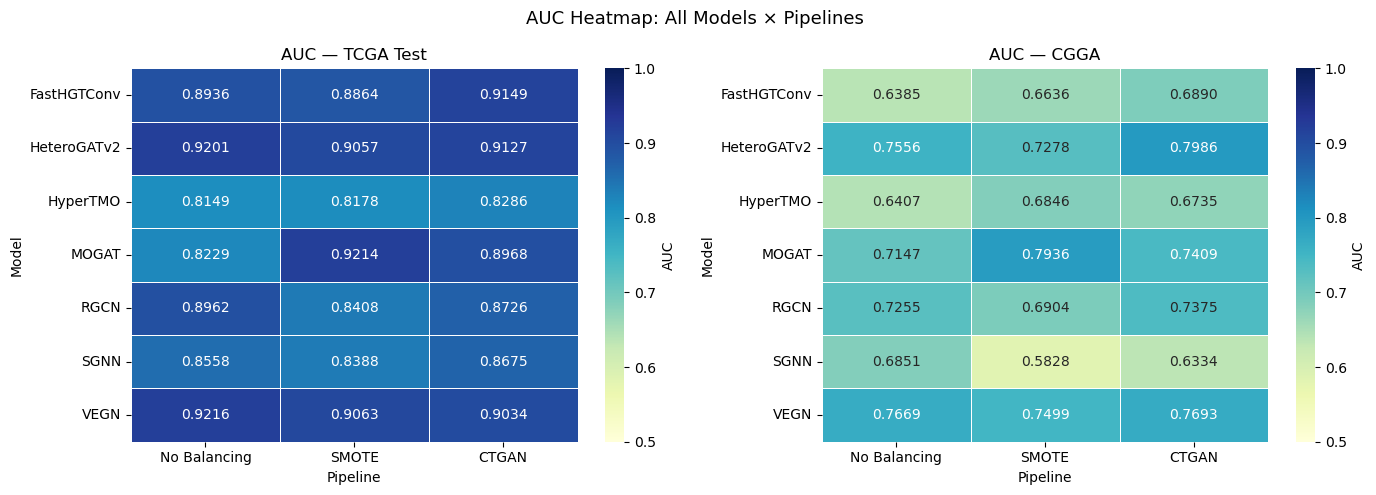

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ds in zip(axes, ['TCGA Test', 'CGGA']):
    # pivot_table with aggfunc='mean' safely handles any duplicate rows
    pivot = (results_df[results_df.Dataset == ds]
             .pivot_table(index='Model', columns='Pipeline',
                          values='AUC', aggfunc='mean')
             .reindex(columns=['No Balancing', 'SMOTE', 'CTGAN']))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
                linewidths=0.5, ax=ax, vmin=0.5, vmax=1.0,
                cbar_kws={'label': 'AUC'})
    ax.set_title(f'AUC — {ds}', fontsize=12)
    ax.set_xlabel('Pipeline'); ax.set_ylabel('Model')
plt.suptitle('AUC Heatmap: All Models × Pipelines', fontsize=13)
plt.tight_layout()
plt.savefig('V10_auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 19. Recall Heatmaps — Grade-1 and Grade-0 (TCGA Test)

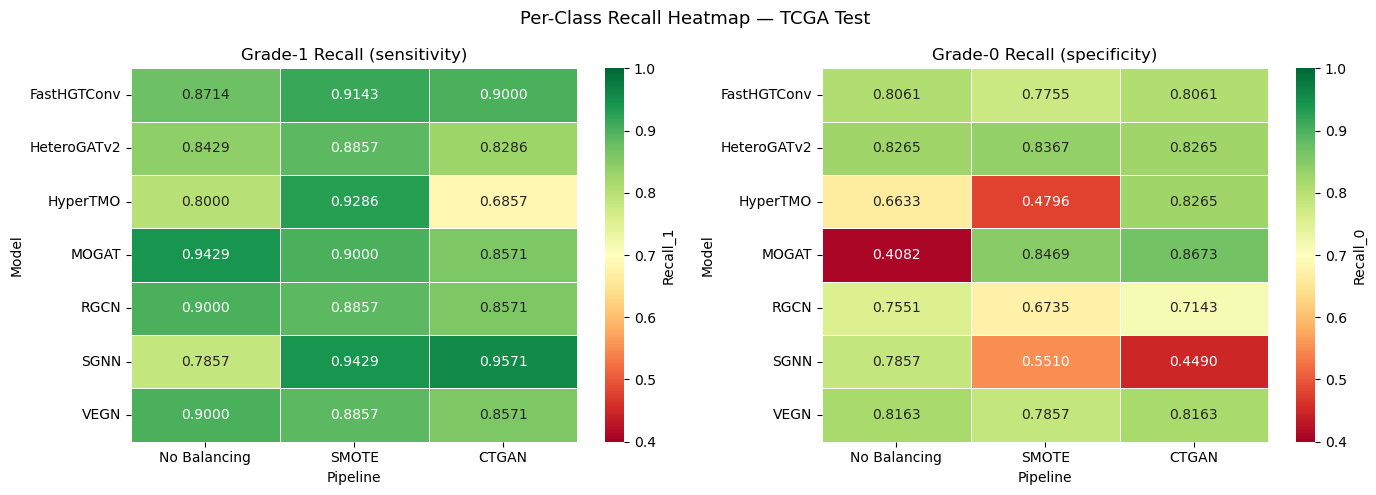

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in [
        (axes[0], 'Recall_1', 'Grade-1 Recall (sensitivity)'),
        (axes[1], 'Recall_0', 'Grade-0 Recall (specificity)')]:
    pivot = (results_df[results_df.Dataset == 'TCGA Test']
             .pivot_table(index='Model', columns='Pipeline',
                          values=col, aggfunc='mean')
             .reindex(columns=['No Balancing', 'SMOTE', 'CTGAN']))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn',
                linewidths=0.5, ax=ax, vmin=0.4, vmax=1.0,
                cbar_kws={'label': col})
    ax.set_title(title); ax.set_xlabel('Pipeline'); ax.set_ylabel('Model')
plt.suptitle('Per-Class Recall Heatmap — TCGA Test', fontsize=13)
plt.tight_layout()
plt.savefig('V10_recall_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 20. 5-Fold CV Box Plots

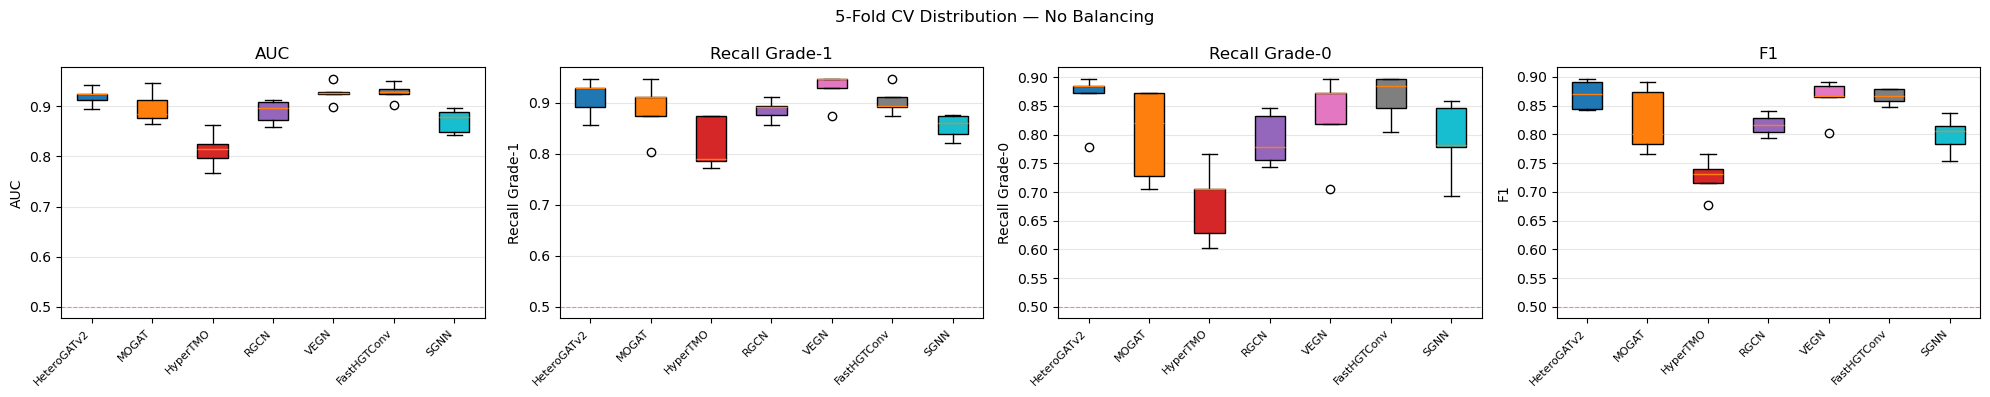

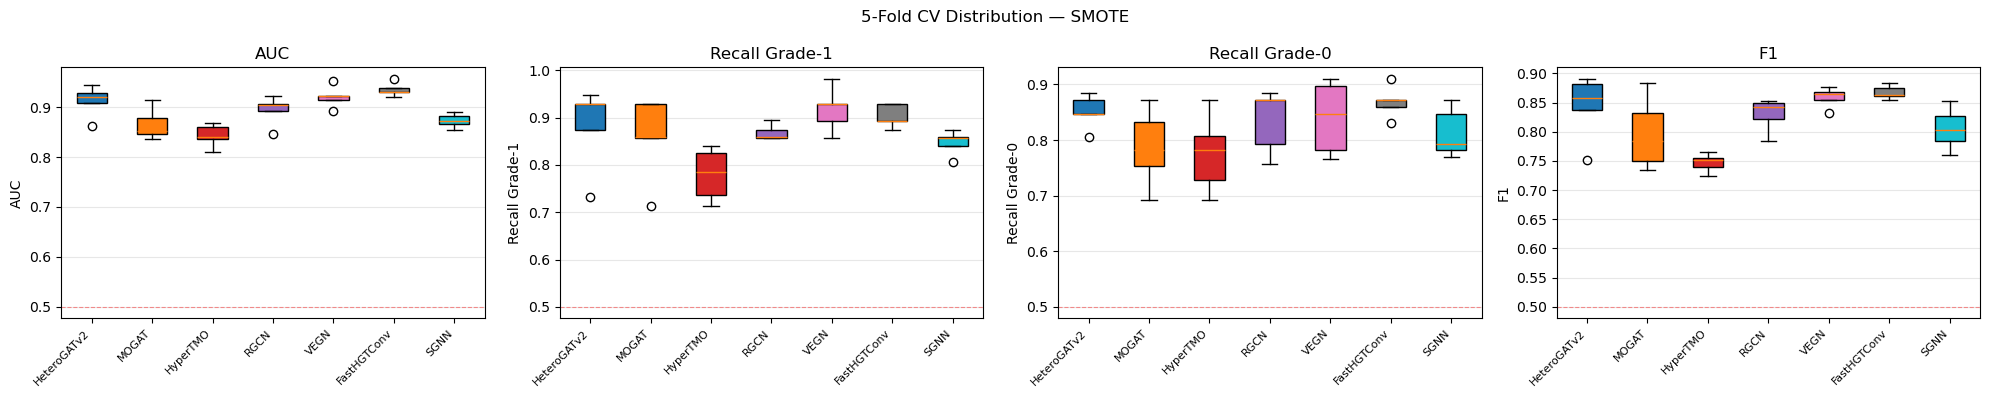

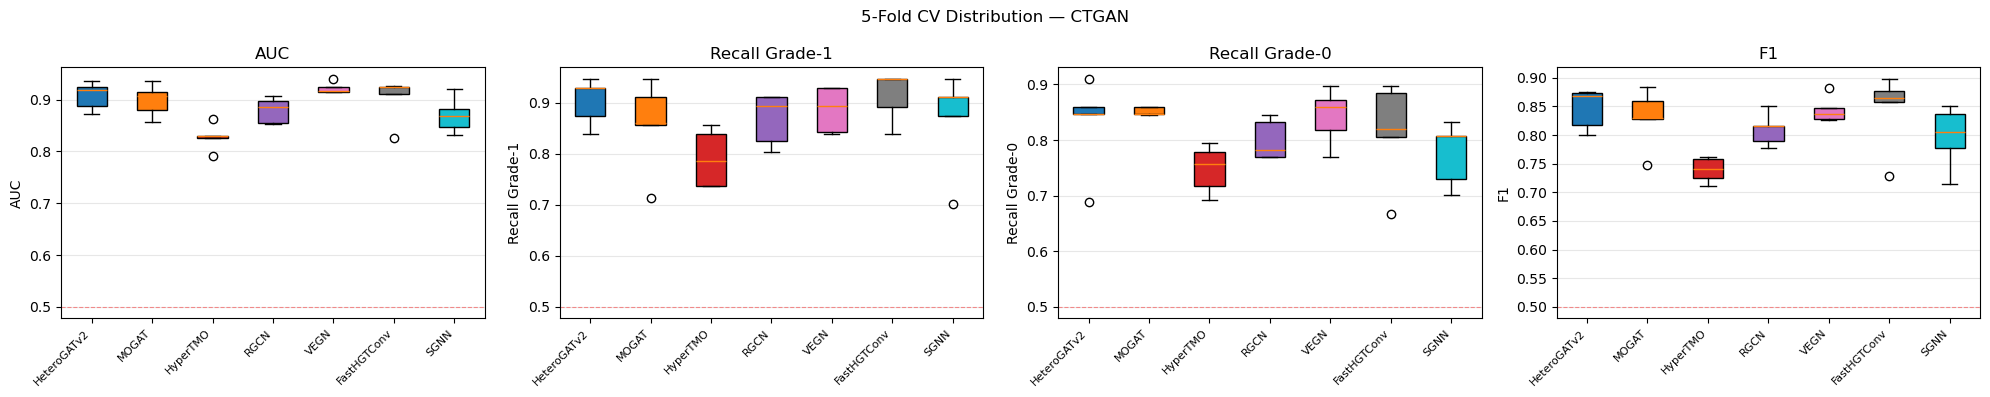

In [20]:
metrics_cv = ['auc', 'recall', 'recall_0', 'f1']
labels_cv  = ['AUC', 'Recall Grade-1', 'Recall Grade-0', 'F1']
model_names = [n for n, _, _ in MODEL_REGISTRY]

for pipe in PIPELINES:
    sub = cv_all[cv_all.Pipeline == pipe]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, met, lab in zip(axes, metrics_cv, labels_cv):
        data = [sub[sub.Model == m][met].values for m in model_names]
        bp = ax.boxplot(data, patch_artist=True, notch=False)
        colors = plt.cm.tab10(np.linspace(0, 0.9, len(model_names)))
        for patch, col in zip(bp['boxes'], colors):
            patch.set_facecolor(col)
        ax.set_xticks(range(1, len(model_names)+1))
        ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel(lab); ax.set_title(lab); ax.grid(axis='y', alpha=0.3)
        ax.axhline(0.5, color='red', ls='--', alpha=0.4, lw=0.8)
    plt.suptitle(f'5-Fold CV Distribution — {pipe}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'V10_cv_boxplot_{pipe.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 21. ROC Curve Grid

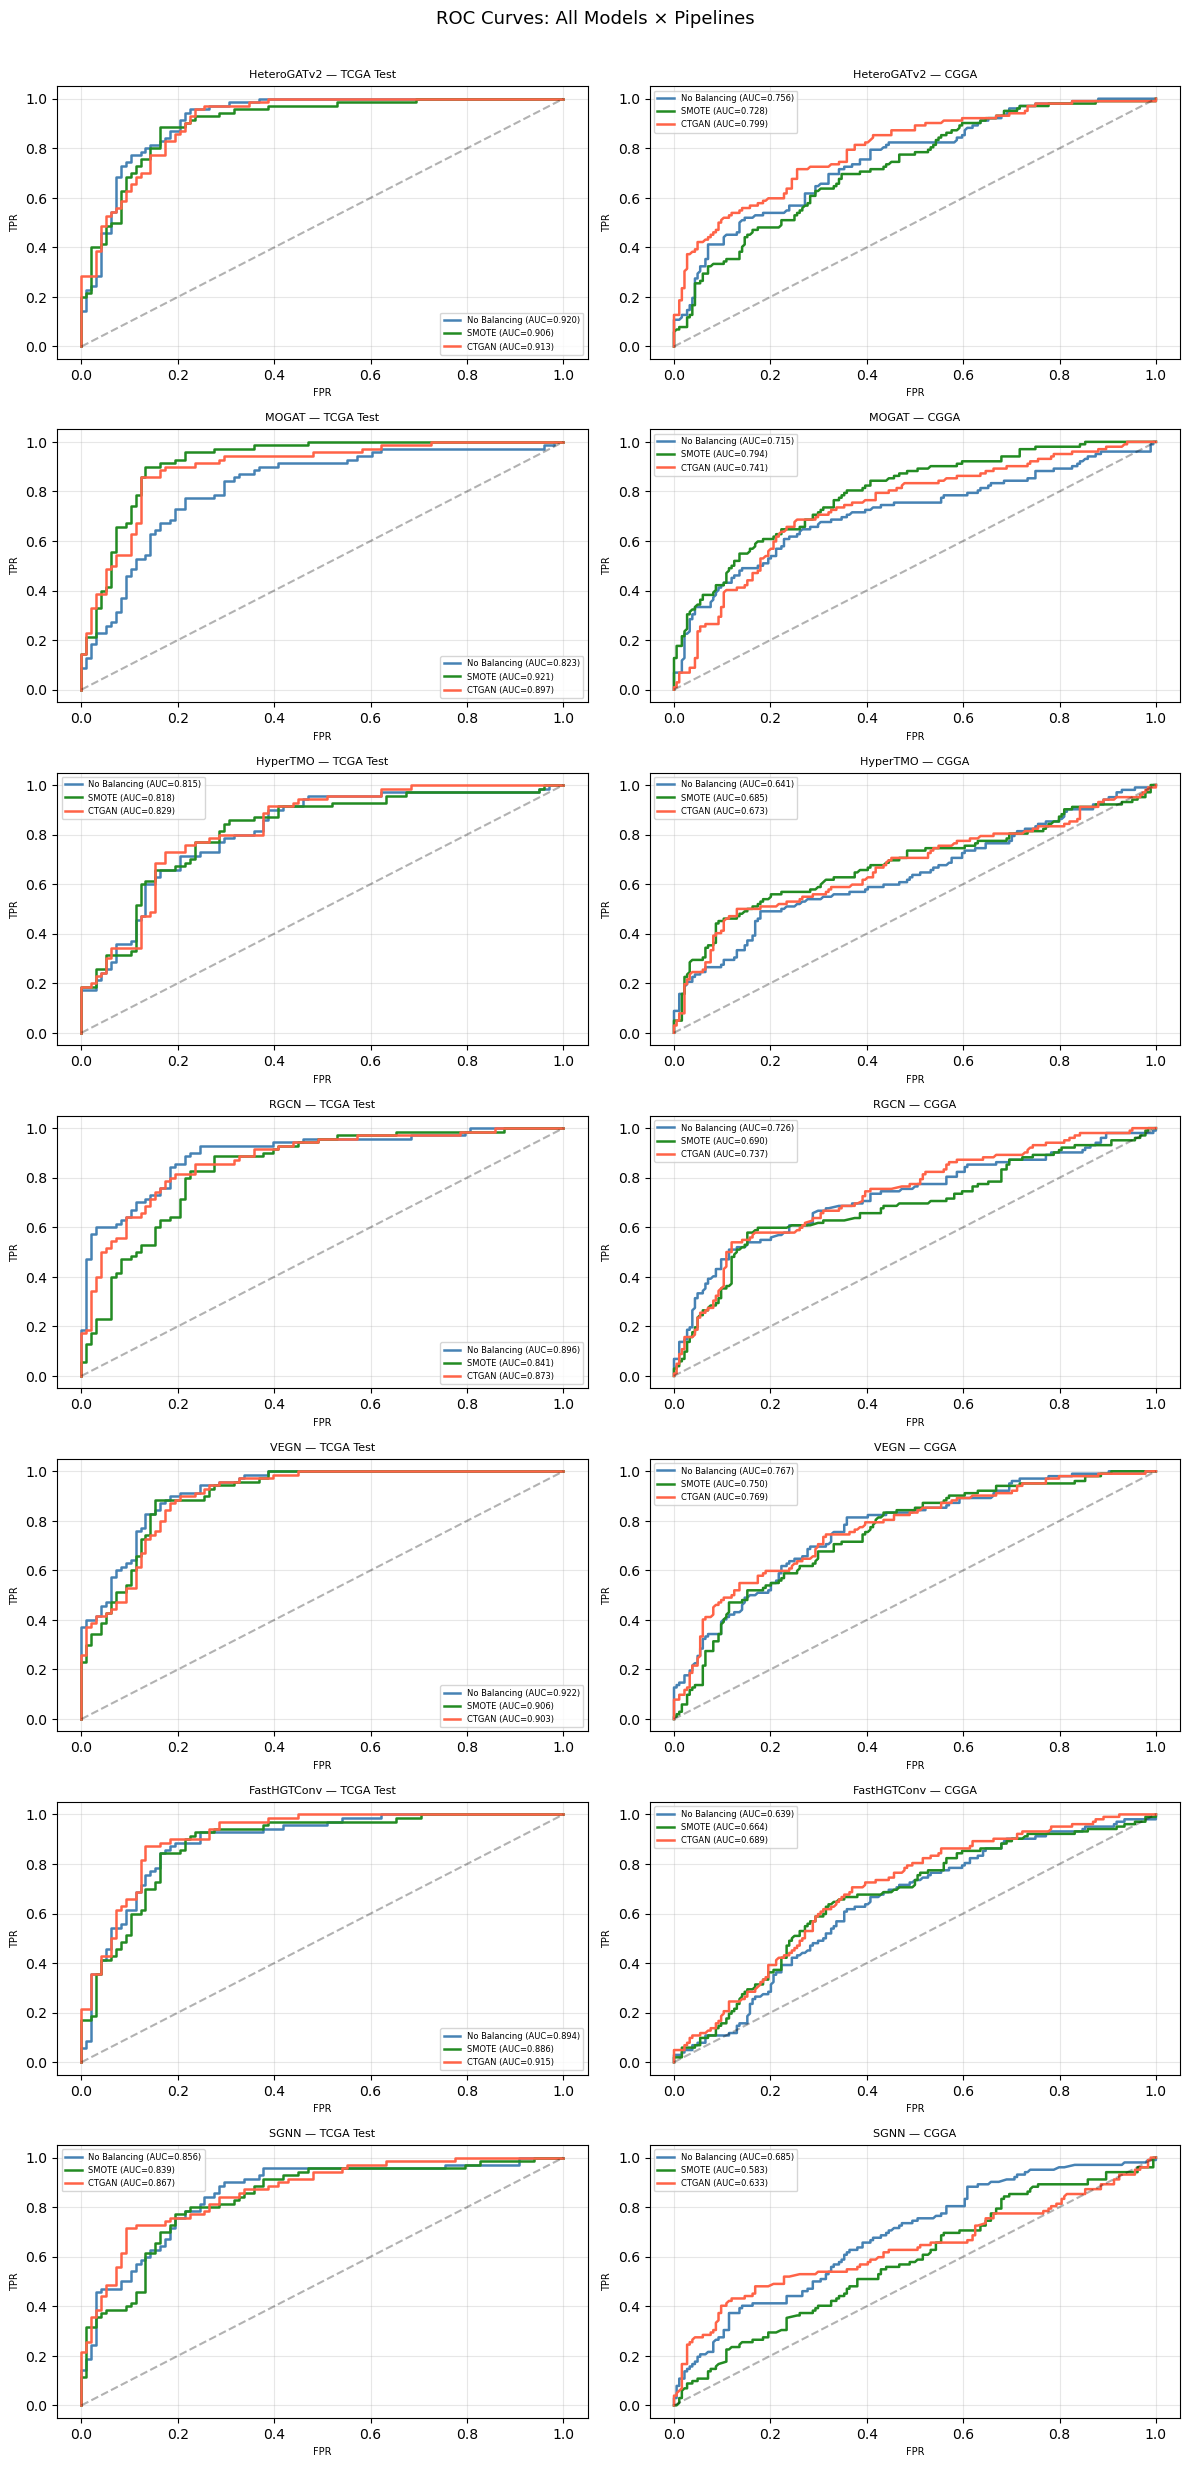

In [21]:
results_full = pd.DataFrame(all_results)
pipe_colors  = {'No Balancing':'steelblue', 'SMOTE':'forestgreen', 'CTGAN':'tomato'}

fig, axes = plt.subplots(len(model_names), 2, figsize=(12, 3.5*len(model_names)))
for row, mname in enumerate(model_names):
    for col, ds in enumerate(['TCGA Test', 'CGGA']):
        ax = axes[row, col]
        for pipe in PIPELINES:
            sub = results_full[(results_full.Model==mname) &
                                (results_full.Pipeline==pipe) &
                                (results_full.Dataset==ds)]
            if sub.empty: continue
            r = sub.iloc[0]
            fpr, tpr, _ = roc_curve(r['labels'], r['probs'])
            ax.plot(fpr, tpr, color=pipe_colors[pipe], lw=1.8,
                    label=f"{pipe} (AUC={r['auc']:.3f})")
        ax.plot([0,1],[0,1],'k--', alpha=0.3)
        ax.set_title(f"{mname} — {ds}", fontsize=8)
        ax.set_xlabel('FPR', fontsize=7); ax.set_ylabel('TPR', fontsize=7)
        ax.legend(fontsize=6); ax.grid(alpha=0.3)
plt.suptitle('ROC Curves: All Models × Pipelines', fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig('V10_roc_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## 22. Confusion Matrices

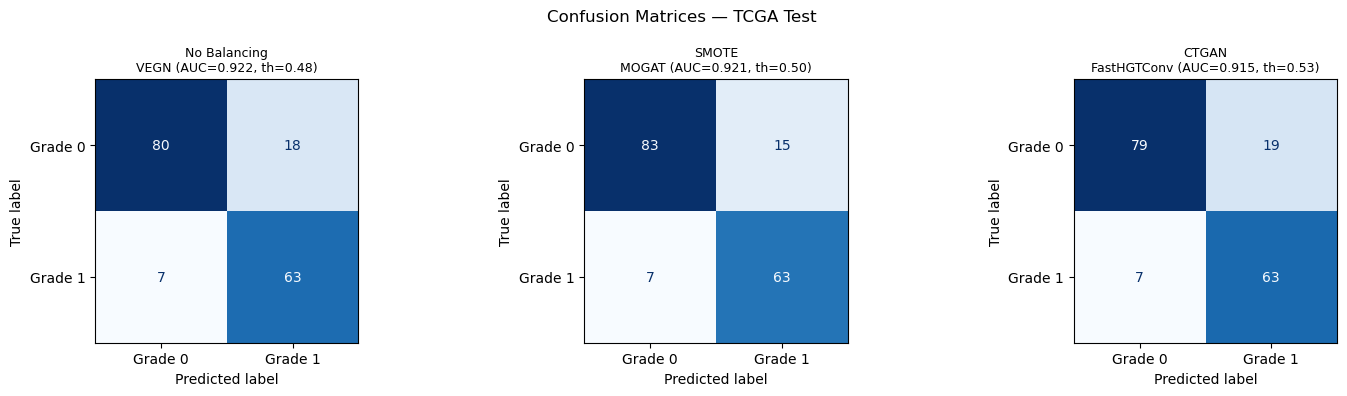

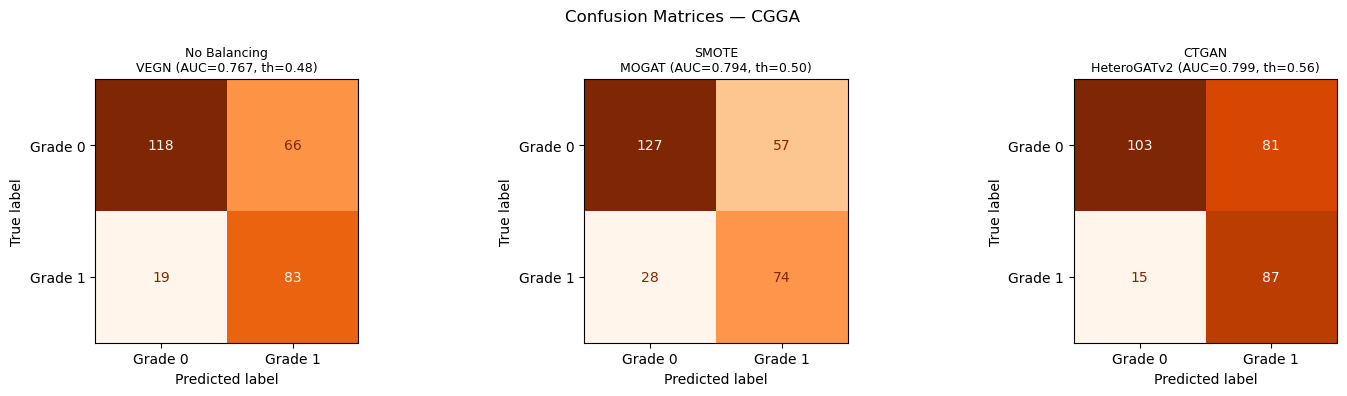

In [22]:
for ds in ['TCGA Test', 'CGGA']:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    cmap = 'Blues' if ds == 'TCGA Test' else 'Oranges'
    for pi, pipe in enumerate(PIPELINES):
        sub  = results_full[(results_full.Dataset==ds) & (results_full.Pipeline==pipe)]
        if sub.empty: continue
        best = sub.loc[sub['auc'].idxmax()]
        th   = best['threshold']
        preds = (best['probs'] >= th).astype(int)
        cm    = confusion_matrix(best['labels'], preds)
        ConfusionMatrixDisplay(cm, display_labels=['Grade 0','Grade 1']).plot(
            ax=axes[pi], cmap=cmap, colorbar=False)
        axes[pi].set_title(f"{pipe}\n{best['Model']} (AUC={best['auc']:.3f}, th={th:.2f})",
                           fontsize=9)
    plt.suptitle(f'Confusion Matrices — {ds}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'V10_cm_{ds.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 23. Permutation Feature Importance — Genes + Clinical Features

For every feature (20 gene mutations + 3 clinical: **Age_at_diagnosis, Gender, Race**),
the column is shuffled `n_repeats=10` times and the mean AUC drop is recorded.

- **Gene features** are permuted as binary mutation columns
- **Clinical features** are permuted as continuous/categorical columns in the same way
- The graph is rebuilt from scratch after each permutation so the message-passing
  structure reflects the shuffled values
- Larger AUC drop → feature is more important for classification

In [23]:
# All features subject to permutation importance
CLINICAL_FEATURES = ['Age_at_diagnosis', 'Gender', 'Race']
ALL_FEATURES      = gene_columns + CLINICAL_FEATURES   # 20 genes + 3 clinical = 23 total


def perm_importance_all(model, ref_df, threshold=0.5, n_repeats=10, seed=0):
    """Permutation importance for ALL features (genes + clinical).
    Returns ({feature: mean_auc_drop}, base_auc).
    """
    base_g = to_dev(construct_bipartite_heterograph(ref_df))
    model.eval()
    with torch.no_grad():
        bp = F.softmax(model(base_g), 1)[:, 1].cpu().numpy()
    try:
        base_auc = roc_auc_score(ref_df['Grade'].values, bp)
    except ValueError:
        return {f: 0.0 for f in ALL_FEATURES}, 0.0

    rng = np.random.default_rng(seed)
    out = {}

    for feat in ALL_FEATURES:
        drops = []
        for _ in range(n_repeats):
            df2         = ref_df.copy()
            df2[feat]   = rng.permutation(df2[feat].values)  # shuffle this feature
            g2          = to_dev(construct_bipartite_heterograph(df2))
            with torch.no_grad():
                pp = F.softmax(model(g2), 1)[:, 1].cpu().numpy()
            try:
                drops.append(base_auc - roc_auc_score(ref_df['Grade'].values, pp))
            except ValueError:
                drops.append(0.0)
        out[feat] = float(np.mean(drops))

    clear_pp_cache()
    return out, base_auc


print("Computing permutation importance for genes + clinical features...")
print(f"Features: {len(ALL_FEATURES)} total ({len(gene_columns)} genes + {len(CLINICAL_FEATURES)} clinical)")
print(f"Models: {len(MODEL_REGISTRY)} × Pipelines: {len(PIPELINES)} = {len(MODEL_REGISTRY)*len(PIPELINES)} combinations")
print(f"Repeats per feature: 10  →  Total graph builds: {len(ALL_FEATURES)*10*len(MODEL_REGISTRY)*len(PIPELINES):,}")

imp_records = []
for mname, MCls, _ in MODEL_REGISTRY:
    for pipe in PIPELINES:
        model = all_models.get((mname, pipe))
        if model is None: continue
        th        = all_thresholds.get((mname, pipe), 0.5)
        imp, base = perm_importance_all(model, test_df, threshold=th)
        for feat, drop in imp.items():
            imp_records.append({
                'Model':        mname,
                'Pipeline':     pipe,
                'Feature':      feat,
                'Feature_Type': 'Clinical' if feat in CLINICAL_FEATURES else 'Gene',
                'AUC_Drop':     drop,
                'Base_AUC':     base,
            })
        print(f"  {mname}/{pipe}  base={base:.4f}")

imp_df = pd.DataFrame(imp_records)
imp_df.to_csv('V10_feature_importance.csv', index=False)
print(f"\nDone. Saved V10_feature_importance.csv ({len(imp_df)} rows)")

Computing permutation importance for genes + clinical features...
Features: 23 total (20 genes + 3 clinical)
Models: 7 × Pipelines: 3 = 21 combinations
Repeats per feature: 10  →  Total graph builds: 4,830
  HeteroGATv2/No Balancing  base=0.9201
  HeteroGATv2/SMOTE  base=0.9057
  HeteroGATv2/CTGAN  base=0.9127
  MOGAT/No Balancing  base=0.8229
  MOGAT/SMOTE  base=0.9214
  MOGAT/CTGAN  base=0.8968
  HyperTMO/No Balancing  base=0.8149
  HyperTMO/SMOTE  base=0.8178
  HyperTMO/CTGAN  base=0.8286
  RGCN/No Balancing  base=0.8962
  RGCN/SMOTE  base=0.8408
  RGCN/CTGAN  base=0.8726
  VEGN/No Balancing  base=0.9216
  VEGN/SMOTE  base=0.9063
  VEGN/CTGAN  base=0.9034
  FastHGTConv/No Balancing  base=0.8936
  FastHGTConv/SMOTE  base=0.8864
  FastHGTConv/CTGAN  base=0.9149
  SGNN/No Balancing  base=0.8558
  SGNN/SMOTE  base=0.8388
  SGNN/CTGAN  base=0.8675

Done. Saved V10_feature_importance.csv (483 rows)


## 24. Feature Importance Plots — Genes + Clinical

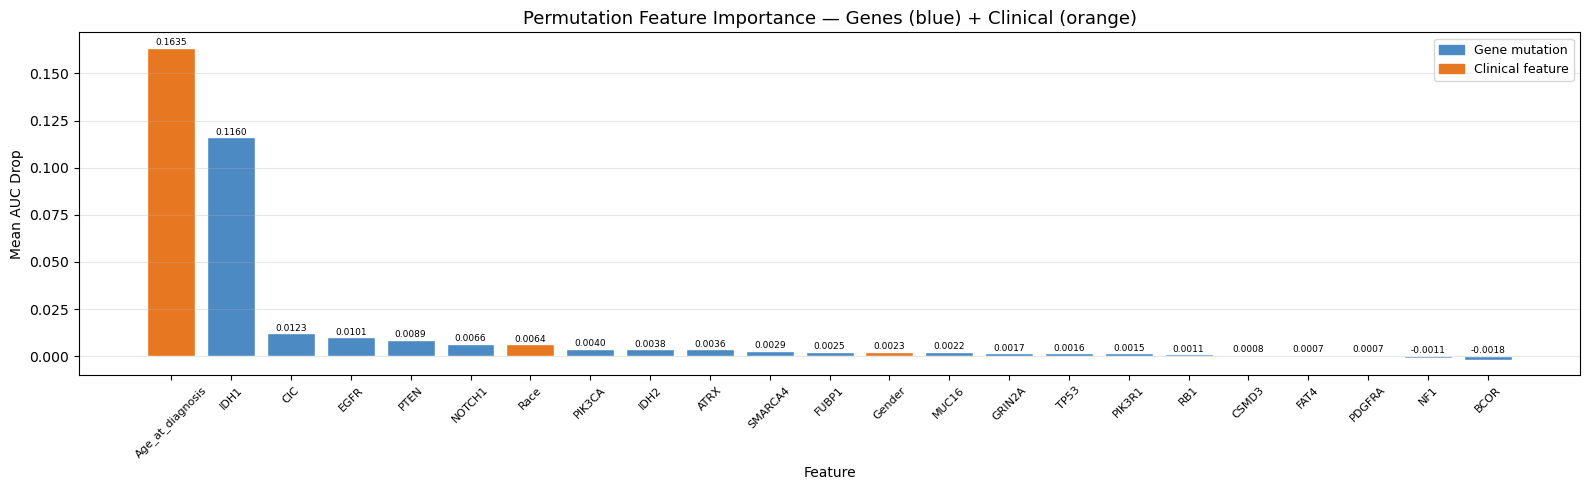

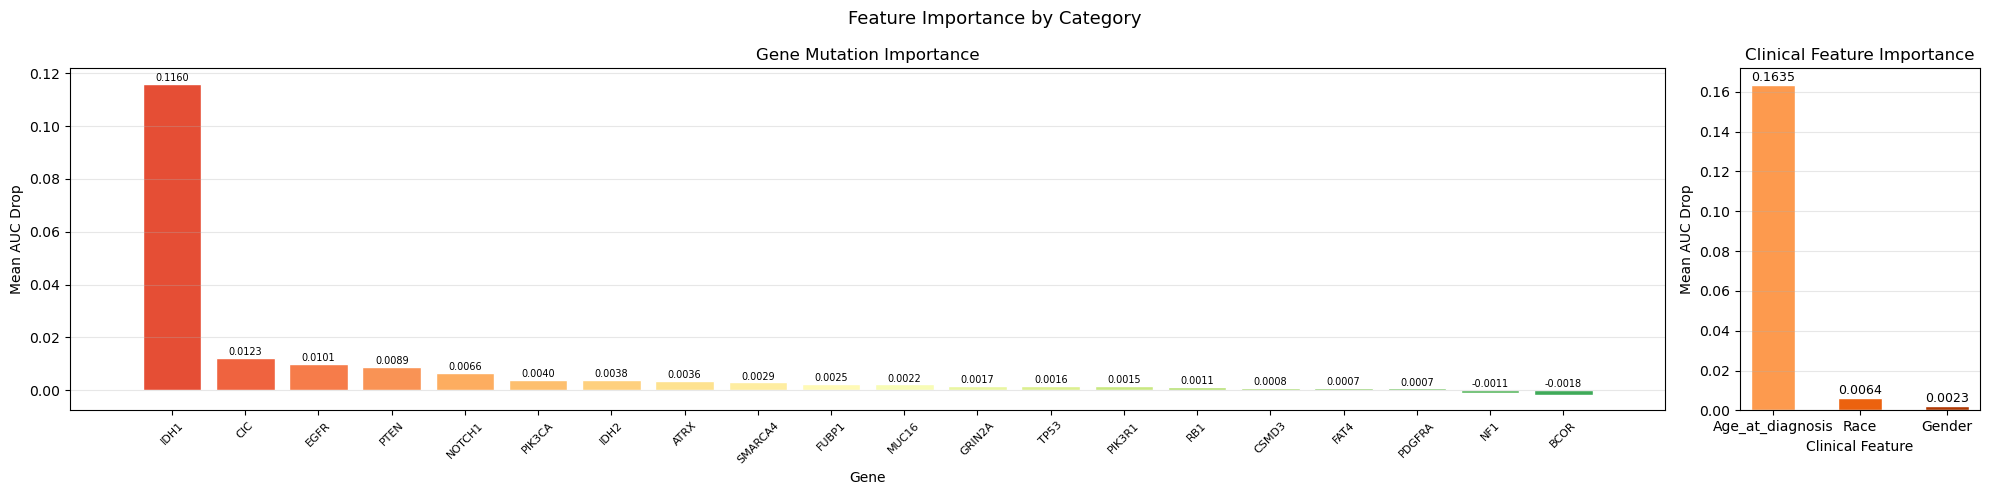

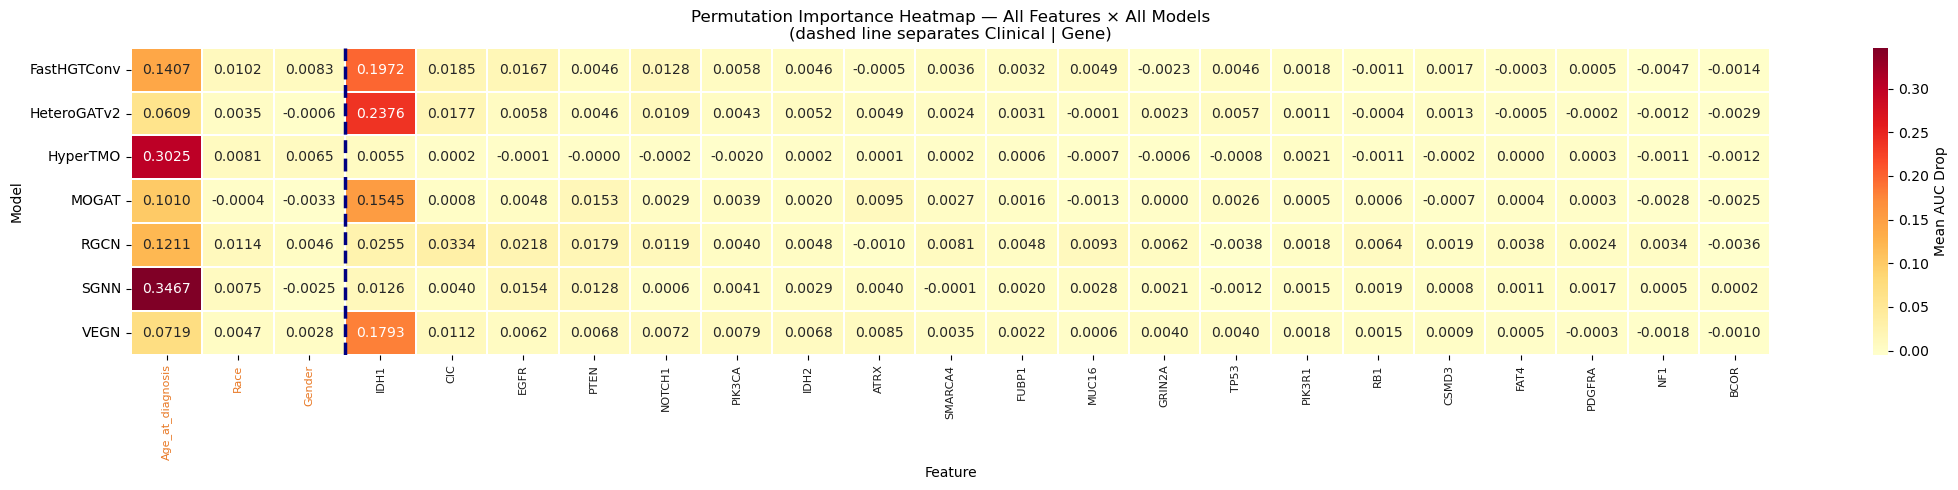

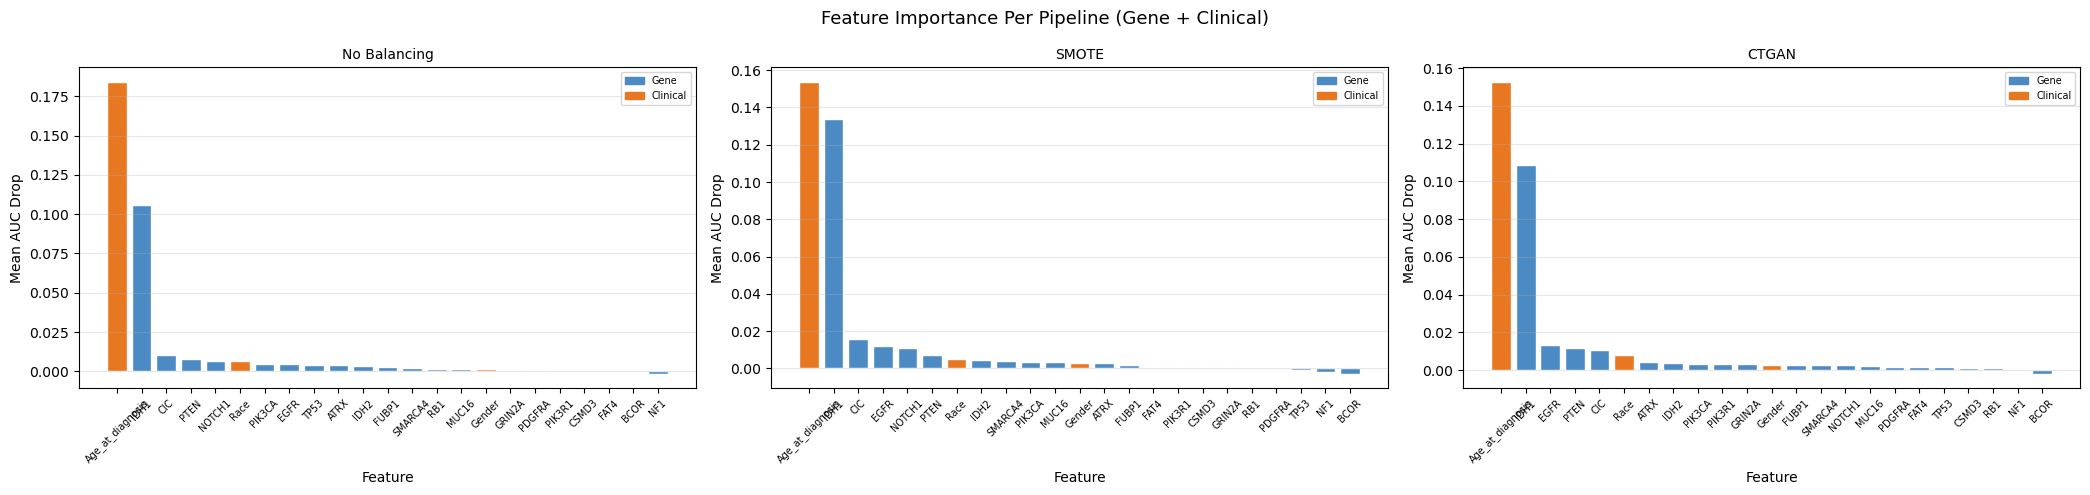


OVERALL FEATURE IMPORTANCE RANKING (mean AUC drop across all models & pipelines)
   1. [CLINICAL]  Age_at_diagnosis      0.1635
   2. [GENE]     IDH1                  0.1160
   3. [GENE]     CIC                   0.0123
   4. [GENE]     EGFR                  0.0101
   5. [GENE]     PTEN                  0.0089
   6. [GENE]     NOTCH1                0.0066
   7. [CLINICAL]  Race                  0.0064
   8. [GENE]     PIK3CA                0.0040
   9. [GENE]     IDH2                  0.0038
  10. [GENE]     ATRX                  0.0036
  11. [GENE]     SMARCA4               0.0029
  12. [GENE]     FUBP1                 0.0025
  13. [CLINICAL]  Gender                0.0023
  14. [GENE]     MUC16                 0.0022
  15. [GENE]     GRIN2A                0.0017
  16. [GENE]     TP53                  0.0016
  17. [GENE]     PIK3R1                0.0015
  18. [GENE]     RB1                   0.0011
  19. [GENE]     CSMD3                 0.0008
  20. [GENE]     FAT4                  0.

In [24]:
# ── Aggregate: mean AUC drop per feature across all models & pipelines ──
mean_imp = (imp_df.groupby(['Feature','Feature_Type'])['AUC_Drop']
            .mean()
            .reset_index()
            .sort_values('AUC_Drop', ascending=False)
            .reset_index(drop=True))

# Colour: orange for clinical, steelblue for gene
bar_colors = ['#E87722' if t == 'Clinical' else '#4C8AC4'
              for t in mean_imp['Feature_Type']]

# ─────────────────────────────────────────────────────────────────
# PLOT A: Combined bar chart — all 23 features, colour-coded by type
# ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(mean_imp['Feature'], mean_imp['AUC_Drop'], color=bar_colors, edgecolor='white')
ax.set_xlabel('Feature'); ax.set_ylabel('Mean AUC Drop')
ax.set_title('Permutation Feature Importance — Genes (blue) + Clinical (orange)', fontsize=13)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.grid(axis='y', alpha=0.3)
for b, v in zip(bars, mean_imp['AUC_Drop']):
    ax.text(b.get_x() + b.get_width()/2, max(v + 0.0003, 0.0005),
            f'{v:.4f}', ha='center', va='bottom', fontsize=6.5)

# Custom legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4C8AC4', label='Gene mutation'),
                    Patch(color='#E87722', label='Clinical feature')],
           fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('V10_feat_importance_combined.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# PLOT B: Side-by-side — Gene panel | Clinical panel
# ─────────────────────────────────────────────────────────────────
gene_imp = mean_imp[mean_imp.Feature_Type == 'Gene'].copy()
clin_imp = mean_imp[mean_imp.Feature_Type == 'Clinical'].copy()

fig, axes = plt.subplots(1, 2, figsize=(20, 5),
                          gridspec_kw={'width_ratios': [len(gene_imp), len(clin_imp)]})

# Gene panel
gcols = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(gene_imp)))
b1 = axes[0].bar(gene_imp['Feature'], gene_imp['AUC_Drop'], color=gcols, edgecolor='white')
axes[0].set_title('Gene Mutation Importance', fontsize=12)
axes[0].set_xlabel('Gene'); axes[0].set_ylabel('Mean AUC Drop')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].grid(axis='y', alpha=0.3)
for b, v in zip(b1, gene_imp['AUC_Drop']):
    axes[0].text(b.get_x() + b.get_width()/2, max(v + 0.0003, 0.0005),
                  f'{v:.4f}', ha='center', va='bottom', fontsize=7)

# Clinical panel
ccols = plt.cm.Oranges(np.linspace(0.45, 0.85, len(clin_imp)))
b2 = axes[1].bar(clin_imp['Feature'], clin_imp['AUC_Drop'], color=ccols, edgecolor='white',
                  width=0.5)
axes[1].set_title('Clinical Feature Importance', fontsize=12)
axes[1].set_xlabel('Clinical Feature'); axes[1].set_ylabel('Mean AUC Drop')
axes[1].tick_params(axis='x', rotation=0, labelsize=10)
axes[1].grid(axis='y', alpha=0.3)
for b, v in zip(b2, clin_imp['AUC_Drop']):
    axes[1].text(b.get_x() + b.get_width()/2, max(v + 0.0003, 0.0005),
                  f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Feature Importance by Category', fontsize=13)
plt.tight_layout()
plt.savefig('V10_feat_importance_sidebyside.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# PLOT C: Heatmap — all 23 features × 7 models (averaged over pipelines)
# ─────────────────────────────────────────────────────────────────
# Column order: clinical first, then genes sorted by mean importance
col_order = (list(clin_imp['Feature']) +
             list(gene_imp.sort_values('AUC_Drop', ascending=False)['Feature']))

heat = (imp_df.groupby(['Model','Feature'])['AUC_Drop']
        .mean()
        .unstack('Feature')
        .reindex(columns=col_order))

fig, ax = plt.subplots(figsize=(22, 5))
sns.heatmap(heat, annot=True, fmt='.4f', cmap='YlOrRd', linewidths=0.35,
            ax=ax, cbar_kws={'label': 'Mean AUC Drop'})

# Vertical separator between clinical and gene columns
ax.axvline(x=len(CLINICAL_FEATURES), color='navy', lw=2.5, ls='--')

ax.set_title('Permutation Importance Heatmap — All Features × All Models\n'
             '(dashed line separates Clinical | Gene)', fontsize=12)

ax.set_xlabel('Feature'); ax.set_ylabel('Model')

# Colour x-tick labels by type
for tick, feat in zip(ax.get_xticklabels(), col_order):
    tick.set_color('#E87722' if feat in CLINICAL_FEATURES else '#1a1a1a')
    tick.set_fontsize(8)

plt.tight_layout()
plt.savefig('V10_feat_importance_heatmap_all.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# PLOT D: Per-pipeline importance — clinical vs gene
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 5))
for pi, pipe in enumerate(PIPELINES):
    sub = (imp_df[imp_df.Pipeline == pipe]
           .groupby(['Feature','Feature_Type'])['AUC_Drop'].mean()
           .reset_index()
           .sort_values('AUC_Drop', ascending=False))
    colors_p = ['#E87722' if t == 'Clinical' else '#4C8AC4'
                for t in sub['Feature_Type']]
    axes[pi].bar(sub['Feature'], sub['AUC_Drop'], color=colors_p, edgecolor='white')
    axes[pi].set_title(f'{pipe}', fontsize=10)
    axes[pi].set_xlabel('Feature'); axes[pi].set_ylabel('Mean AUC Drop')
    axes[pi].tick_params(axis='x', rotation=45, labelsize=7)
    axes[pi].grid(axis='y', alpha=0.3)
    axes[pi].legend(handles=[Patch(color='#4C8AC4', label='Gene'),
                               Patch(color='#E87722', label='Clinical')],
                     fontsize=7)
plt.suptitle('Feature Importance Per Pipeline (Gene + Clinical)', fontsize=13)
plt.tight_layout()
plt.savefig('V10_feat_importance_per_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# Summary table
# ─────────────────────────────────────────────────────────────────
print("\nOVERALL FEATURE IMPORTANCE RANKING (mean AUC drop across all models & pipelines)")
print("="*65)
for i, row in mean_imp.iterrows():
    tag = '[CLINICAL]' if row['Feature_Type'] == 'Clinical' else '[GENE]   '
    print(f"  {i+1:2d}. {tag}  {row['Feature']:20s}  {row['AUC_Drop']:.4f}")

print(f"\nClinical features summary:")
for _, row in clin_imp.iterrows():
    print(f"  {row['Feature']:20s}: {row['AUC_Drop']:.4f}")

print(f"\nTop-5 gene features:")
for _, row in gene_imp.head(5).iterrows():
    print(f"  {row['Feature']:20s}: {row['AUC_Drop']:.4f}")

## 25. GAT & MOGAT Attention Weights

**HeteroGATv2**: gene→patient GATv2 attention.  
**MOGAT**: same gene→patient GATv2 genomic attention **plus** the fusion gate values showing how much each patient relies on the genomic vs clinical pathway.


Attention: HeteroGATv2 / No Balancing


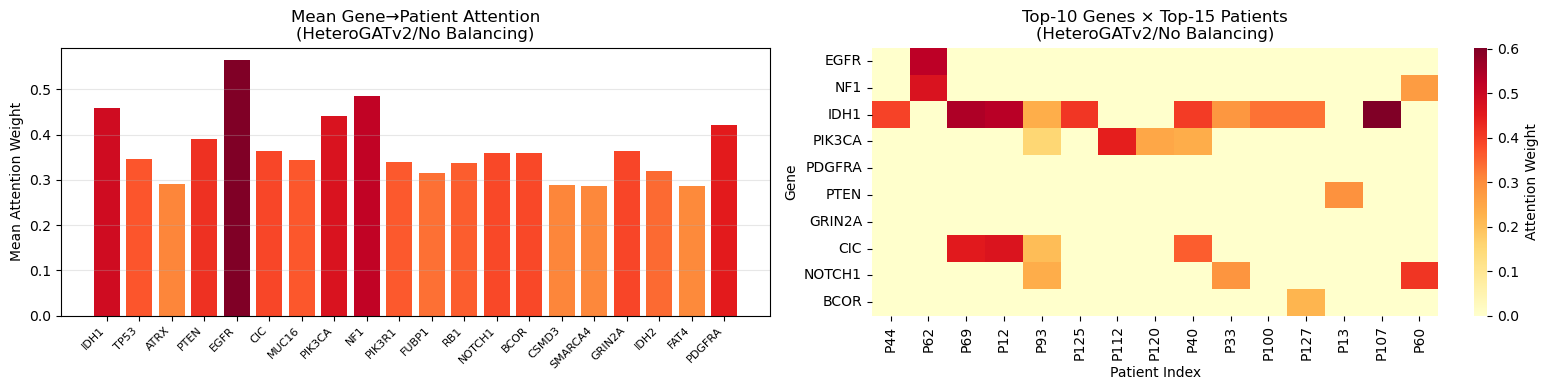


Attention: MOGAT / No Balancing
  MOGAT has no get_attn_weights — skipping.


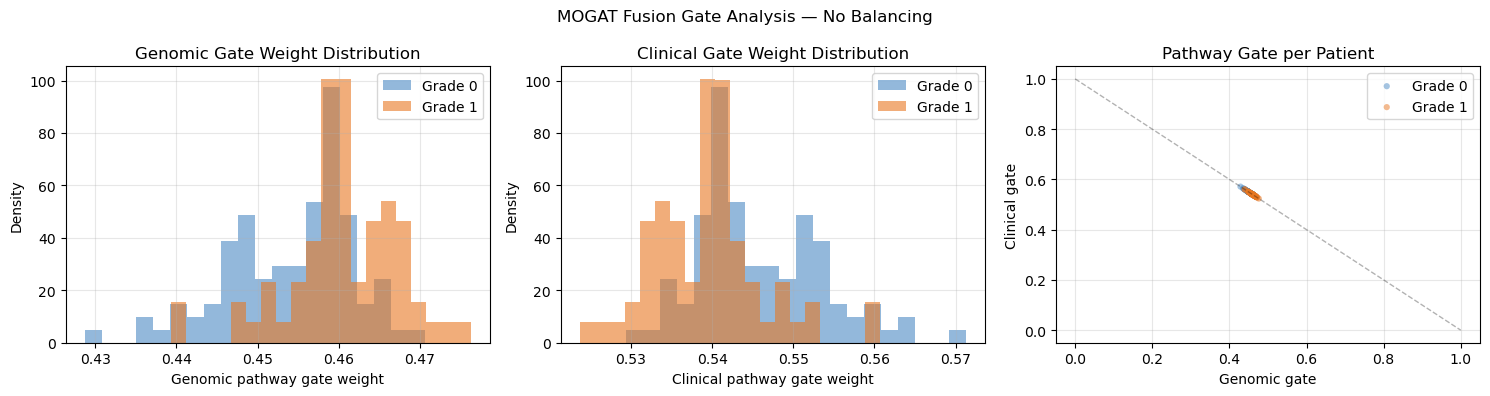


Attention: HeteroGATv2 / SMOTE


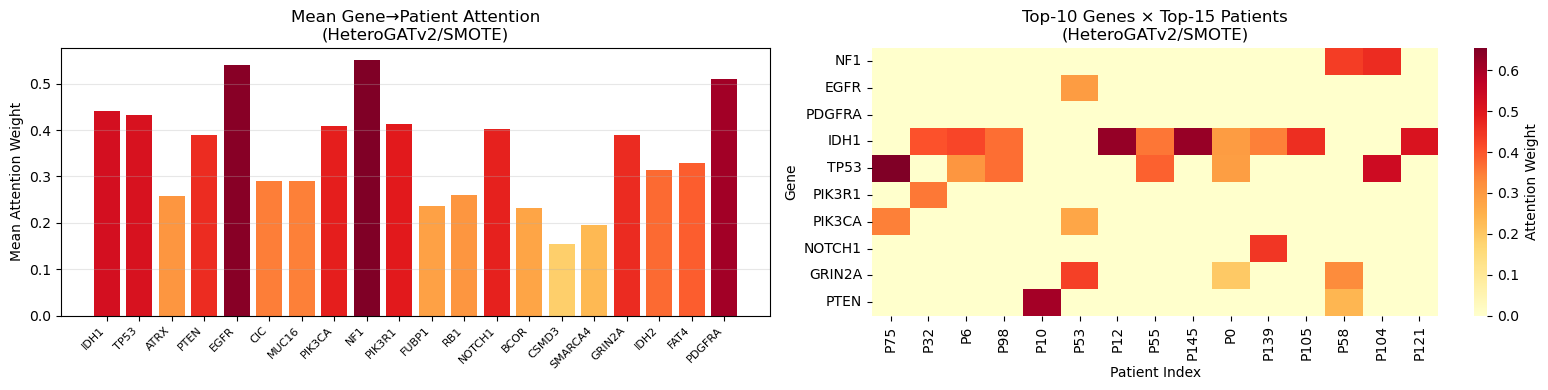


Attention: MOGAT / SMOTE
  MOGAT has no get_attn_weights — skipping.


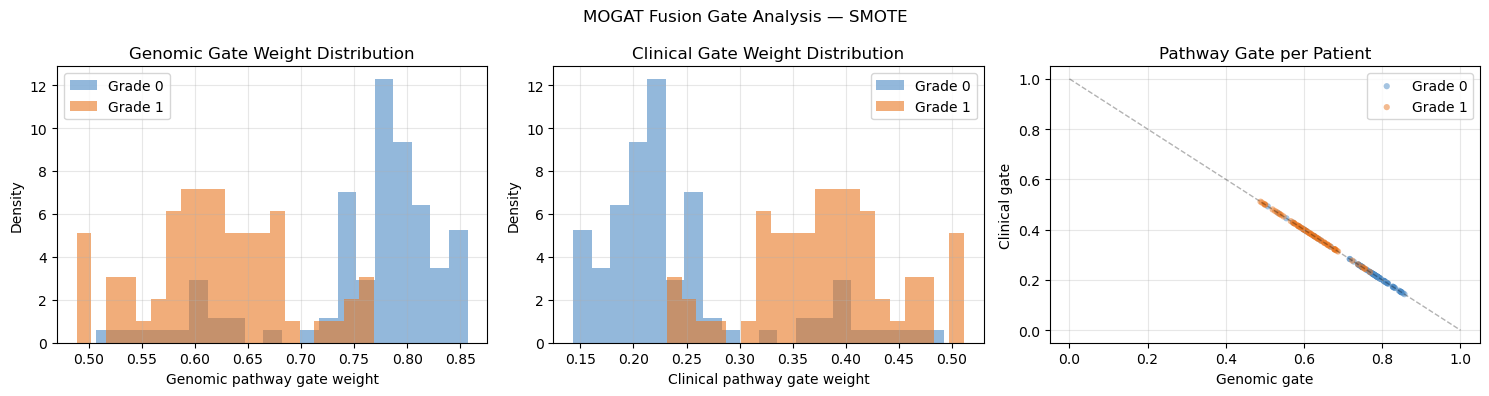


Attention: HeteroGATv2 / CTGAN


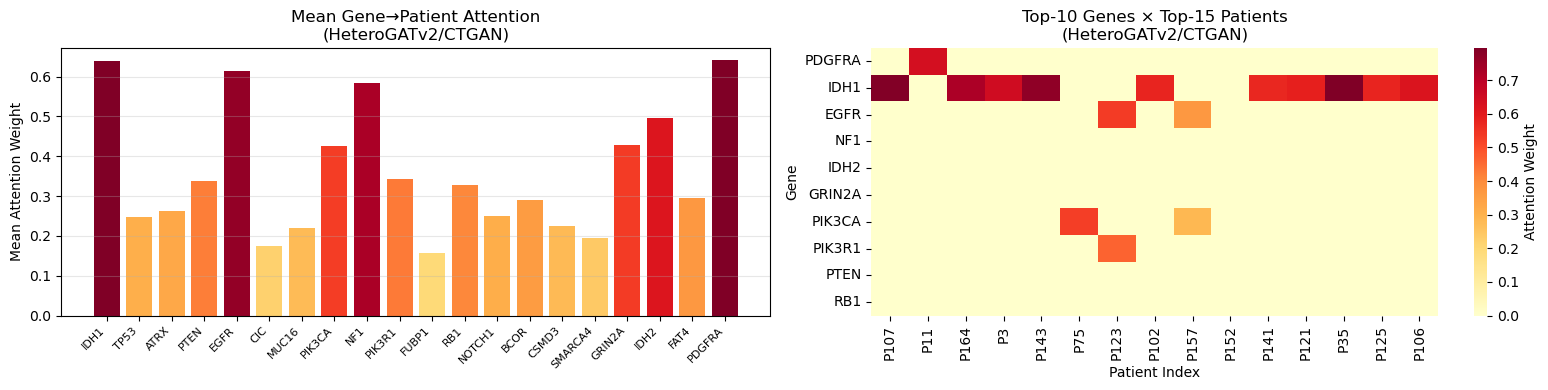


Attention: MOGAT / CTGAN
  MOGAT has no get_attn_weights — skipping.


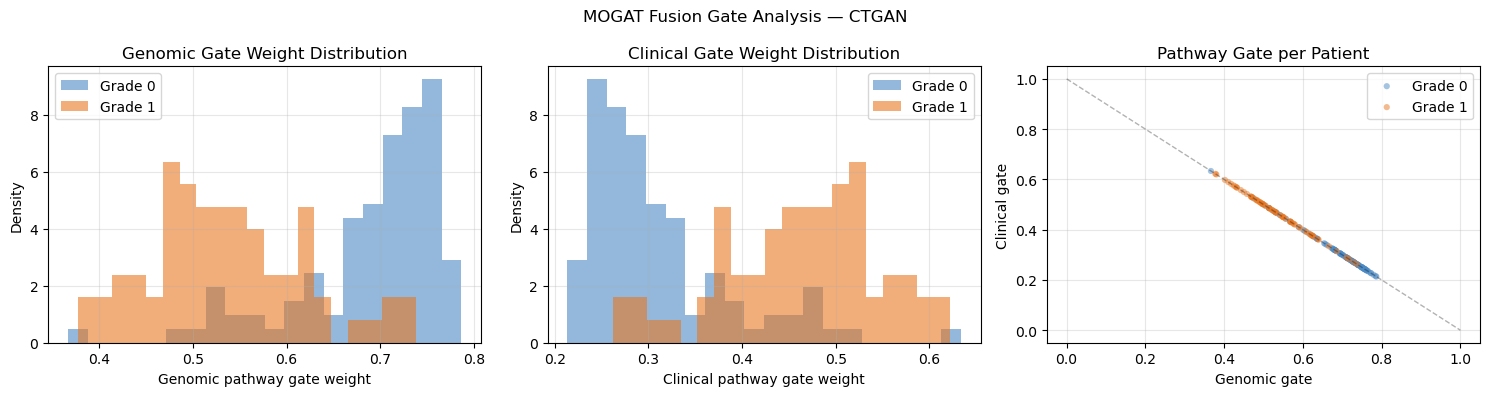

In [25]:
def plot_gene_attention(model, graph, ref_df, title):
    """Visualise gene->patient attention for any model that exposes get_attn_weights().
    For MOGAT the function also prints the fusion gate split (printed inside get_attn_weights).
    """
    model.eval()
    if not hasattr(model, 'get_attn_weights'):
        print(f"  {type(model).__name__} has no get_attn_weights — skipping.")
        return
    try:
        eidx, weights = model.get_attn_weights(graph)
    except Exception as e:
        print(f"  Attention extraction failed: {e}"); return

    gene_ids = eidx[0].cpu().numpy()
    pat_ids  = eidx[1].cpu().numpy()
    w        = weights.cpu().numpy()

    # Mean attention weight per gene (averaged over all edges touching that gene)
    gene_attn = np.zeros(NUM_GENES); gene_cnt = np.zeros(NUM_GENES)
    for g, wt in zip(gene_ids, w):
        if 0 <= g < NUM_GENES:
            gene_attn[g] += wt; gene_cnt[g] += 1
    gene_cnt  = np.maximum(gene_cnt, 1)
    gene_attn /= gene_cnt

    # Top-10 genes and top-15 patients by total received attention
    n_pat = ref_df.shape[0]
    top_g  = np.argsort(gene_attn)[::-1][:10]
    pat_wsum = np.zeros(n_pat)
    for g, p, wt in zip(gene_ids, pat_ids, w):
        if 0 <= p < n_pat: pat_wsum[p] += wt
    top_p = np.argsort(pat_wsum)[::-1][:15]

    mat = np.zeros((len(top_g), len(top_p)))
    for g_loc, g in enumerate(top_g):
        for p_loc, p in enumerate(top_p):
            mask = (gene_ids == g) & (pat_ids == p)
            if mask.any(): mat[g_loc, p_loc] = w[mask].mean()

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Bar chart: mean attention per gene
    norm_a = gene_attn / (gene_attn.max() + 1e-9)
    axes[0].bar(gene_columns, gene_attn, color=plt.cm.YlOrRd(norm_a))
    axes[0].set_xticklabels(gene_columns, rotation=45, ha='right', fontsize=8)
    axes[0].set_title(f'Mean Gene→Patient Attention\n({title})')
    axes[0].set_ylabel('Mean Attention Weight'); axes[0].grid(axis='y', alpha=0.3)

    # Heatmap: top genes × top patients
    sns.heatmap(mat, ax=axes[1], cmap='YlOrRd',
                xticklabels=[f'P{p}' for p in top_p],
                yticklabels=[gene_columns[g] for g in top_g],
                cbar_kws={'label': 'Attention Weight'})
    axes[1].set_title(f'Top-10 Genes × Top-15 Patients\n({title})')
    axes[1].set_xlabel('Patient Index'); axes[1].set_ylabel('Gene')

    plt.tight_layout()
    safe = title.replace('/','_').replace(' ','_')
    plt.savefig(f'V10_attn_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── MOGAT: also show per-patient fusion gate distribution ─────────
def plot_mogat_fusion_gate(model, graph, ref_df, title):
    """Show the distribution of genomic vs clinical pathway weights
    (the learned soft gate) across all patients."""
    model.eval()
    if not isinstance(model, MOGAT):
        return
    with torch.no_grad():
        e   = graph[('Gene','mutates','Patient')].edge_index
        hpg = F.relu(model.pg(graph['Patient'].x))
        hgg = F.relu(model.gg(graph['Gene'].x))
        hpg_out = F.leaky_relu(model.gat((hgg, hpg), e), 0.2)
        hpc     = model.mlp(F.relu(model.pc(graph['Patient'].x)))
        gate_w  = torch.softmax(model.gate(torch.cat([hpg_out, hpc], -1)), dim=-1)
        gw      = gate_w.cpu().numpy()   # [n_patients, 2]  col0=genomic, col1=clinical

    labels  = ref_df['Grade'].values
    grades  = ['Grade 0', 'Grade 1']
    colors  = ['#4C8AC4', '#E87722']

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Histogram of genomic gate weight
    for grade, color, lbl in zip([0,1], colors, grades):
        mask = (labels == grade)
        axes[0].hist(gw[mask, 0], bins=20, alpha=0.6, color=color, label=lbl, density=True)
    axes[0].set_xlabel('Genomic pathway gate weight'); axes[0].set_ylabel('Density')
    axes[0].set_title('Genomic Gate Weight Distribution'); axes[0].legend(); axes[0].grid(alpha=0.3)

    # Histogram of clinical gate weight
    for grade, color, lbl in zip([0,1], colors, grades):
        mask = (labels == grade)
        axes[1].hist(gw[mask, 1], bins=20, alpha=0.6, color=color, label=lbl, density=True)
    axes[1].set_xlabel('Clinical pathway gate weight'); axes[1].set_ylabel('Density')
    axes[1].set_title('Clinical Gate Weight Distribution'); axes[1].legend(); axes[1].grid(alpha=0.3)

    # Scatter: genomic vs clinical gate per patient, coloured by grade
    for grade, color, lbl in zip([0,1], colors, grades):
        mask = (labels == grade)
        axes[2].scatter(gw[mask, 0], gw[mask, 1], c=color, label=lbl,
                         alpha=0.5, s=20, edgecolors='none')
    axes[2].plot([0,1],[1,0],'k--', alpha=0.3, lw=1)   # gate sums to 1
    axes[2].set_xlabel('Genomic gate'); axes[2].set_ylabel('Clinical gate')
    axes[2].set_title('Pathway Gate per Patient'); axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.suptitle(f'MOGAT Fusion Gate Analysis — {title}', fontsize=12)
    plt.tight_layout()
    safe = title.replace('/','_').replace(' ','_')
    plt.savefig(f'V10_mogat_gate_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── Run for HeteroGATv2 and MOGAT across all pipelines ───────────
for pipe in PIPELINES:
    for mname in ['HeteroGATv2', 'MOGAT']:
        m = all_models.get((mname, pipe))
        if m is None: continue
        print(f"\nAttention: {mname} / {pipe}")
        plot_gene_attention(m, test_graph, test_df, f"{mname}/{pipe}")
        if mname == 'MOGAT':
            plot_mogat_fusion_gate(m, test_graph, test_df, f"{pipe}")

## 26. Classification Reports — Best Model Overall

In [26]:
for ds in ['TCGA Test','CGGA']:
    sub  = results_full[results_full.Dataset==ds]
    best = sub.loc[sub['auc'].idxmax()]
    th   = best['threshold']
    preds  = (best['probs'] >= th).astype(int)
    labels = best['labels']
    print(f"{'='*65}")
    print(f"Best on {ds}: {best['Model']} / {best['Pipeline']}")
    print(f"AUC={best['auc']:.4f}  Threshold={th:.3f}")
    print(classification_report(labels, preds, target_names=['Grade 0','Grade 1']))

Best on TCGA Test: VEGN / No Balancing
AUC=0.9216  Threshold=0.478
              precision    recall  f1-score   support

     Grade 0       0.92      0.82      0.86        98
     Grade 1       0.78      0.90      0.83        70

    accuracy                           0.85       168
   macro avg       0.85      0.86      0.85       168
weighted avg       0.86      0.85      0.85       168

Best on CGGA: HeteroGATv2 / CTGAN
AUC=0.7986  Threshold=0.558
              precision    recall  f1-score   support

     Grade 0       0.87      0.56      0.68       184
     Grade 1       0.52      0.85      0.64       102

    accuracy                           0.66       286
   macro avg       0.70      0.71      0.66       286
weighted avg       0.75      0.66      0.67       286



## 27. Save Results

In [29]:
# import os
# os.makedirs('saved_models_v10', exist_ok=True)
# for (mname, pipe), model in all_models.items():
#     fn = f"saved_models_v10/{mname}_{pipe.replace(' ','_')}.pth"
#     torch.save(model.state_dict(), fn)

pd.DataFrame([{'Model': mn, 'Pipeline': pp, 'Threshold': th}
               for (mn, pp), th in all_thresholds.items()]).to_csv('V10_thresholds.csv', index=False)
if 'imp_df' in dir() and not imp_df.empty:
    imp_df.to_csv('V10_feature_importance.csv', index=False)
    print("✓ Exported: V10_feature_importance.csv")

print("✓ Saved model weights to saved_models_v10/")
print("\nFinal AUC Pivot:")
print(results_df.pivot_table(index='Model', columns=['Pipeline','Dataset'],
                              values='AUC', aggfunc='mean').round(4).to_string())

✓ Exported: V10_feature_importance.csv
✓ Saved model weights to saved_models_v10/

Final AUC Pivot:
Pipeline      CTGAN           No Balancing             SMOTE          
Dataset        CGGA TCGA Test         CGGA TCGA Test    CGGA TCGA Test
Model                                                                 
FastHGTConv  0.6890    0.9149       0.6385    0.8936  0.6636    0.8864
HeteroGATv2  0.7986    0.9127       0.7556    0.9201  0.7278    0.9057
HyperTMO     0.6735    0.8286       0.6407    0.8149  0.6846    0.8178
MOGAT        0.7409    0.8968       0.7147    0.8229  0.7936    0.9214
RGCN         0.7375    0.8726       0.7255    0.8962  0.6904    0.8408
SGNN         0.6334    0.8675       0.6851    0.8558  0.5828    0.8388
VEGN         0.7693    0.9034       0.7669    0.9216  0.7499    0.9063


## 28. DAHGNN — Domain-Adversarial Heterogeneous GNN

### Why CGGA is harder — measured covariate shifts

| Feature | TCGA | CGGA | Impact |
|---------|------|------|--------|
| **Race** | 91% white, 7% Black | **100% Asian** | Model learns Race as shortcut → collapses on CGGA |
| **Age** | mean 50.9 ± 15.7 | mean 42.0 ± 12.3 | BatchNorm memorises TCGA stats |
| **PTEN** | 16.8% | 6.6% | −10% mutation frequency shift |
| **EGFR** | 13.3% | 3.8% | −9.5% shift |

### Key fixes in this cell block

- **Snapshot isolation**: `_baseline_results_df` and `_baseline_all_results` are frozen at the start of this section so re-running DAHGNN cells never contaminates V10 baseline values
- **No lazy Linear(-1,...)**: all input sizes explicit → `.parameters()` works at construction
- **InstanceNorm** on clinical branch: per-sample normalisation, no TCGA stat memorisation
- **GRL**: Gradient Reversal Layer forces domain-invariant encoder representations
- **Domain-confidence gate**: gate receives domain logit → suppresses clinical when CGGA shift detected

**Loss:** `L = FocalLoss(grade | TCGA only) + λ · BCE(domain | TCGA=0, CGGA=1)` — λ annealed 0→1

In [ ]:
# ══════════════════════════════════════════════════════════════════
# FIX: Snapshot baseline results BEFORE any DAHGNN training.
# This guarantees re-running this cell block never changes the
# V10 baseline numbers shown in the comparison plots/tables.
# ══════════════════════════════════════════════════════════════════
import copy as _copy

_baseline_results_df  = results_df.copy()           # frozen V10 table
_baseline_all_results = _copy.deepcopy(all_results)  # frozen V10 raw results

print(f"Baseline snapshot frozen: {len(_baseline_results_df)} rows, "
      f"{_baseline_results_df['Model'].nunique()} models")
print("Baseline top CGGA AUC:",
      _baseline_results_df[_baseline_results_df.Dataset=='CGGA']['AUC'].max())
print("Baseline top TCGA AUC:",
      _baseline_results_df[_baseline_results_df.Dataset=='TCGA Test']['AUC'].max())

# ══════════════════════════════════════════════════════════════════
# DAHGNN model definition
# Input sizes are fixed and known — NO lazy Linear(-1,...) anywhere.
# ══════════════════════════════════════════════════════════════════
_PAT_IN  = 3          # Gender, Race, Age_normalized
_GENE_IN = NUM_GENES  # 20  — identity-matrix gene features


class _GRLFunc(torch.autograd.Function):
    """Gradient Reversal: identity forward, negated gradient backward."""
    @staticmethod
    def forward(ctx, x, lam):
        ctx.lam = lam
        return x.clone()
    @staticmethod
    def backward(ctx, grad):
        return -ctx.lam * grad, None

class GradientReversal(nn.Module):
    def forward(self, x, lam=1.0):
        return _GRLFunc.apply(x, lam)


class DAHGNN(nn.Module):
    """Domain-Adversarial Heterogeneous GNN for TCGA→CGGA transfer.

    Encoder : bidirectional GATv2 on Gene-Patient bipartite graph.
    Clinical : MLP with InstanceNorm (no TCGA-stat memorisation).
    Gate     : domain-confidence-aware soft blend of both paths.
    GRL      : gradient reversal makes encoder domain-invariant.
    Classifier: trained on TCGA grade labels only.
    CGGA     : contributes only to domain loss (labels never used).
    """

    def __init__(self, hidden_dim=64, out_dim=2, num_heads=4, dropout=0.15,
                 pat_in=_PAT_IN, gene_in=_GENE_IN, **_):
        super().__init__()
        self.dr = dropout

        # ── Shared GATv2 encoder — explicit input sizes ───────────
        self.p_lin  = nn.Linear(pat_in,    hidden_dim)   # 3  → hd
        self.g_lin  = nn.Linear(gene_in,   hidden_dim)   # 20 → hd
        self.g2p    = GATv2Conv(hidden_dim, hidden_dim,
                                 heads=num_heads, concat=False,
                                 add_self_loops=False)
        self.p2g    = GATv2Conv(hidden_dim, hidden_dim,
                                 heads=num_heads, concat=False,
                                 add_self_loops=False)
        self.p_skip = nn.Linear(hidden_dim, hidden_dim)
        self.g_skip = nn.Linear(hidden_dim, hidden_dim)

        # ── Clinical branch with InstanceNorm ─────────────────────
        self.pc       = nn.Linear(pat_in,  hidden_dim)   # 3 → hd
        self.clin_fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.clin_in1 = nn.InstanceNorm1d(hidden_dim, affine=True)
        self.clin_fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.clin_in2 = nn.InstanceNorm1d(hidden_dim, affine=True)

        # ── Domain-confidence-aware gate ──────────────────────────
        # input = [h_gnn | h_clin | domain_conf] → size 2*hd + 1
        self.gate = nn.Linear(hidden_dim * 2 + 1, 2)

        # ── Grade classifier ──────────────────────────────────────
        self.clf = nn.Linear(hidden_dim, out_dim)

        # ── GRL + domain discriminator ────────────────────────────
        self.grl = GradientReversal()
        self.domain_clf = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def _encode_gnn(self, graph):
        ei  = graph.edge_index_dict
        hp  = F.relu(self.p_lin(graph['Patient'].x))
        hg  = F.relu(self.g_lin(graph['Gene'].x))
        hp  = self.p_skip(hp) + self.g2p((hg, hp), ei[('Gene','mutates','Patient')])
        hg  = self.g_skip(hg) + self.p2g((hp, hg), ei[('Patient','mutated_by','Gene')])
        return F.dropout(F.leaky_relu(hp, 0.2), self.dr, training=self.training)

    def _encode_clin(self, graph):
        """InstanceNorm1d on [N,C]: unsqueeze→[1,N,C], norm, squeeze."""
        h = F.relu(self.pc(graph['Patient'].x))
        h = F.relu(self.clin_in1(self.clin_fc1(h).unsqueeze(0)).squeeze(0))
        h = F.dropout(h, self.dr, training=self.training)
        h = F.relu(self.clin_in2(self.clin_fc2(h).unsqueeze(0)).squeeze(0))
        return h

    def forward(self, graph, lam=0.0):
        """Returns (grade_logits [N,2], domain_logits [N,1])."""
        h_gnn  = self._encode_gnn(graph)
        h_clin = self._encode_clin(graph)

        h_rev         = self.grl(h_gnn, lam)
        domain_logits = self.domain_clf(h_rev)

        domain_conf   = torch.sigmoid(domain_logits.detach())   # [N,1]
        gate_input    = torch.cat([h_gnn, h_clin, domain_conf], dim=-1)
        gate_w        = torch.softmax(self.gate(gate_input), dim=-1)

        h_fused      = gate_w[:, :1] * h_gnn + gate_w[:, 1:] * h_clin
        grade_logits = self.clf(h_fused)
        return grade_logits, domain_logits

    def predict(self, graph):
        """Inference: grade logits only, GRL inactive (lam=0)."""
        logits, _ = self.forward(graph, lam=0.0)
        return logits

    def get_attn_weights(self, graph):
        """GATv2 gene→patient attention for visualisation."""
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        _, (eidx, alpha) = self.g2p(
            (hg, hp), ei[('Gene','mutates','Patient')],
            return_attention_weights=True)
        return eidx, alpha.detach().mean(dim=-1)


# Verify all params are initialized immediately (no lazy modules)
_tmp = DAHGNN(hidden_dim=64)
_n   = sum(p.numel() for p in _tmp.parameters())
del _tmp
print(f"\nDAHGNN defined — {_n:,} params, all initialized at construction.")


In [ ]:
def _dann_lam(epoch, max_ep):
    """DANN lambda schedule: 0→1 over training."""
    p = epoch / max(max_ep, 1)
    return float(2.0 / (1.0 + np.exp(-10.0 * p)) - 1.0)


def train_dahgnn(tcga_tr_g, tcga_val_g, cgga_unlab_g,
                  params, max_epochs=MAX_EPOCHS, patience=PATIENCE):
    """Train DAHGNN with adversarial domain alignment.
    CGGA labels are NEVER used — only domain signal (TCGA=0, CGGA=1).
    """
    model = DAHGNN(
        hidden_dim=params['hidden_dim'], out_dim=2,
        num_heads=params['num_heads'],  dropout=params['dropout'],
    ).to(device)

    opt = torch.optim.AdamW(
        model.parameters(), lr=params['lr'],
        weight_decay=params['weight_decay'])
    sch = CosineAnnealingLR(opt, T_max=max_epochs, eta_min=params['lr'] * 0.05)
    dom_crit = nn.BCEWithLogitsLoss()

    n_t = tcga_tr_g['Patient'].x.shape[0]
    n_c = cgga_unlab_g['Patient'].x.shape[0]
    lbl_t = torch.zeros(n_t, 1, device=device)   # TCGA = 0
    lbl_c = torch.ones(n_c,  1, device=device)   # CGGA = 1

    best_auc, ctr, best_state, history = 0.0, 0, None, []

    for epoch in range(max_epochs):
        lam = _dann_lam(epoch, max_epochs)
        model.train(); opt.zero_grad()

        # Grade loss on TCGA (labelled)
        grade_log, dom_log_t = model(tcga_tr_g, lam=lam)
        grade_loss = criterion(grade_log, tcga_tr_g['Patient'].y)

        # Domain loss: TCGA branch
        dom_loss_t = dom_crit(dom_log_t, lbl_t)

        # Domain loss: CGGA branch (no grade labels)
        _, dom_log_c = model(cgga_unlab_g, lam=lam)
        dom_loss_c = dom_crit(dom_log_c, lbl_c)

        # Total loss — GRL already negates domain gradient internally
        loss = grade_loss + lam * (dom_loss_t + dom_loss_c) / 2.0
        loss.backward(); opt.step(); sch.step()

        # Validation AUC on TCGA val set
        model.eval()
        with torch.no_grad():
            vp = F.softmax(model.predict(tcga_val_g), 1)[:, 1].cpu().numpy()
            vl = tcga_val_g['Patient'].y.cpu().numpy()
        try:
            auc = roc_auc_score(vl, vp)
        except ValueError:
            auc = 0.0
        history.append(auc)

        if auc > best_auc:
            best_auc, ctr = auc, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            ctr += 1
            if ctr >= patience:
                break

    return best_auc, best_state, history


def run_optuna_dahgnn(tcga_tr_g, tcga_val_g, cgga_unlab,
                       n_trials=N_TRIALS, label='DAHGNN'):
    """Optuna HPO for DAHGNN — same interface as run_optuna()."""
    def objective(trial):
        p = {
            'hidden_dim':   trial.suggest_categorical('hidden_dim', [32, 64, 128]),
            'num_heads':    trial.suggest_categorical('num_heads',  [2, 4, 8]),
            'dropout':      trial.suggest_float('dropout', 0.05, 0.25, step=0.05),
            'lr':           trial.suggest_float('lr', 1e-4, 5e-3, log=True),
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True),
        }
        auc, _, _ = train_dahgnn(tcga_tr_g, tcga_val_g, cgga_unlab, p)
        return auc

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    bp = study.best_params
    print(f"  [{label}] Best Val AUC={study.best_value:.4f}  params={bp}")
    _, best_state, _ = train_dahgnn(tcga_tr_g, tcga_val_g, cgga_unlab, bp)
    return bp, best_state, study


print("DAHGNN training + Optuna functions defined.")


In [ ]:
print("=" * 65)
print("DAHGNN — Domain-Adversarial (TCGA labeled + CGGA unlabeled)")
print("=" * 65)

# CGGA graph for domain alignment — grade labels in .y are NEVER
# passed to the grade loss, only to the domain discriminator loss.
cgga_unlab = to_dev(construct_bipartite_heterograph(cgga_df))

# DAHGNN-specific result containers — completely separate from
# all_results / results_df so baseline values are never touched.
dahgnn_raw    = []   # raw dicts with probs/labels (like all_results)
dahgnn_models = {}   # {pipe_name: trained DAHGNN model}
dahgnn_ths    = {}   # {pipe_name: calibrated threshold}

for pipe_name, aug_fn in [('No Balancing', None), ('SMOTE', apply_smote)]:
    print(f"\n── Pipeline: {pipe_name} ──")

    # ── Optuna HPO (on train_df split for speed) ─────────────────
    hpo_df = aug_fn(train_df.copy()) if aug_fn else train_df
    hpo_gr = to_dev(construct_bipartite_heterograph(hpo_df))
    bp, _, _ = run_optuna_dahgnn(hpo_gr, val_graph, cgga_unlab,
                                  label=f"DAHGNN/{pipe_name}")

    # ── Final model on full train_val ─────────────────────────────
    full_df = aug_fn(train_val_df.copy()) if aug_fn else train_val_df
    clear_pp_cache()
    full_gr = to_dev(construct_bipartite_heterograph(full_df))
    _, final_state, _ = train_dahgnn(full_gr, val_graph, cgga_unlab, bp)

    # ── Build final model ─────────────────────────────────────────
    m = DAHGNN(hidden_dim=bp['hidden_dim'], out_dim=2,
                num_heads=bp['num_heads'], dropout=bp['dropout']).to(device)
    m.load_state_dict(final_state)

    # ── Threshold calibration on val set ─────────────────────────
    m.eval()
    with torch.no_grad():
        vp = F.softmax(m.predict(val_graph), 1)[:, 1].cpu().numpy()
        vl = val_graph['Patient'].y.cpu().numpy()
    th = find_optimal_threshold(vp, vl)
    dahgnn_ths[pipe_name] = th
    print(f"  Calibrated threshold (G-mean on val): {th:.3f}")

    # ── Evaluate on TCGA test + CGGA ─────────────────────────────
    for ds_name, ds_gr in [('TCGA Test', test_graph), ('CGGA', cgga_graph)]:
        m.eval()
        with torch.no_grad():
            probs  = F.softmax(m.predict(ds_gr), 1)[:, 1].cpu().numpy()
            labels = ds_gr['Patient'].y.cpu().numpy()
        preds = (probs >= th).astype(int)
        met   = compute_metrics(preds, probs, labels)
        print(f"  {ds_name:10s}  AUC={met['auc']:.4f}  "
              f"R1={met['recall']:.3f}  R0={met['recall_0']:.3f}  "
              f"F1={met['f1']:.4f}")
        rec = {'Model': 'DAHGNN', 'Pipeline': pipe_name,
               'Dataset': ds_name, 'threshold': th,
               'probs': probs, 'labels': labels}
        rec.update(met)
        dahgnn_raw.append(rec)

    dahgnn_models[pipe_name] = m
    clear_pp_cache()

print("\n✓ DAHGNN complete.")
print("  NOTE: all_results and results_df are UNCHANGED (baseline preserved).")
print(f"  Baseline top CGGA AUC still: "
      f"{_baseline_results_df[_baseline_results_df.Dataset=='CGGA']['AUC'].max()}")


In [ ]:
from matplotlib.patches import Patch

# ── Build DAHGNN summary dataframe ───────────────────────────────
dahgnn_df = pd.DataFrame([
    {'Model':     r['Model'],
     'Pipeline':  r['Pipeline'],
     'Dataset':   r['Dataset'],
     'AUC':       round(r['auc'],       4),
     'Accuracy':  round(r['accuracy'],  4),
     'Precision': round(r['precision'], 4),
     'Recall_1':  round(r['recall'],    4),
     'Recall_0':  round(r['recall_0'],  4),
     'F1':        round(r['f1'],        4),
     'Threshold': round(r['threshold'], 3)}
    for r in dahgnn_raw
])

# ── Use FROZEN baseline — not the live results_df ─────────────────
# This guarantees comparison values match exactly what V10 produced
# regardless of how many times these cells are re-run.
_bl = _baseline_results_df   # shorthand

print("\n" + "="*90)
print("COMPARISON — DAHGNN vs V10 BASELINE")
print("="*90)

for ds in ['TCGA Test', 'CGGA']:
    print(f"\n{'─'*90}")
    print(f"Dataset: {ds}")
    print(f"{'─'*90}")

    top5 = (_bl[_bl.Dataset == ds]
            .sort_values('AUC', ascending=False)
            .head(5)[['Model','Pipeline','AUC','Recall_1','Recall_0','F1']])

    dah  = (dahgnn_df[dahgnn_df.Dataset == ds]
            [['Model','Pipeline','AUC','Recall_1','Recall_0','F1']])

    combined = pd.concat([top5, dah], ignore_index=True)
    combined.insert(0, 'Type',
        ['Baseline']*len(top5) + ['DAHGNN']*len(dah))
    print(combined.to_string(index=False))

    # Delta vs best baseline
    best_bl_auc = top5['AUC'].iloc[0]
    for _, row in dah.iterrows():
        delta = row['AUC'] - best_bl_auc
        sign  = '+' if delta >= 0 else ''
        print(f"  DAHGNN/{row['Pipeline']} vs best baseline: "
              f"ΔAUC={sign}{delta:.4f}")

# ── Horizontal bar chart ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, ds in zip(axes, ['TCGA Test', 'CGGA']):
    base = (_bl[_bl.Dataset == ds]
            .sort_values('AUC', ascending=False)
            .drop_duplicates('Model')
            [['Model','Pipeline','AUC']]
            .copy())
    base['Label'] = base['Model'] + ' (' + base['Pipeline'] + ')'

    dah = (dahgnn_df[dahgnn_df.Dataset == ds]
           [['Model','Pipeline','AUC']].copy())
    dah['Label'] = dah['Model'] + ' (' + dah['Pipeline'] + ')'

    df_plot = pd.concat([base, dah], ignore_index=True).sort_values('AUC')
    colors  = ['#E87722' if 'DAHGNN' in m else '#4C8AC4'
               for m in df_plot['Model']]

    ax.barh(df_plot['Label'], df_plot['AUC'],
            color=colors, edgecolor='white', height=0.6)
    ax.set_xlim(0.45, 1.02)
    ax.axvline(0.5, color='red', ls='--', alpha=0.3, lw=1)

    # Mark best baseline
    best_bl = base['AUC'].max()
    ax.axvline(best_bl, color='#4C8AC4', ls=':', alpha=0.5, lw=1.5,
               label=f'Best baseline ({best_bl:.4f})')

    ax.set_xlabel('AUC'); ax.set_title(f'{ds}', fontsize=11)
    ax.grid(axis='x', alpha=0.3)
    for j, (_, row) in enumerate(df_plot.iterrows()):
        ax.text(row['AUC'] + 0.004, j,
                f"{row['AUC']:.4f}", va='center', fontsize=7.5)

fig.legend(handles=[
    Patch(color='#E87722', label='DAHGNN (domain-adaptive)'),
    Patch(color='#4C8AC4', label='V10 baseline models')],
    loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.03))
plt.suptitle('DAHGNN vs V10 Baseline — AUC (frozen baseline values)',
             fontsize=13)
plt.tight_layout()
plt.savefig('V10_dahgnn_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── ROC curves (baseline from frozen snapshot) ────────────────────
_bl_full = pd.DataFrame(_baseline_all_results)  # has probs + labels

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, ds in zip(axes, ['TCGA Test', 'CGGA']):
    # Best baseline ROC (from frozen snapshot)
    sub_bl = _bl_full[_bl_full.Dataset == ds]
    best_b = sub_bl.loc[sub_bl['auc'].idxmax()]
    fpr_b, tpr_b, _ = roc_curve(best_b['labels'], best_b['probs'])
    ax.plot(fpr_b, tpr_b, color='#4C8AC4', lw=2.5,
            label=f"Best baseline: {best_b['Model']} "
                  f"(AUC={best_b['auc']:.4f})")

    # DAHGNN ROC curves
    ls_map = {'No Balancing': '--', 'SMOTE': '-.'}
    colors_d = {'No Balancing': '#E87722', 'SMOTE': '#C04000'}
    for r in dahgnn_raw:
        if r['Dataset'] != ds:
            continue
        fpr_d, tpr_d, _ = roc_curve(r['labels'], r['probs'])
        ax.plot(fpr_d, tpr_d,
                color=colors_d[r['Pipeline']],
                lw=2, ls=ls_map[r['Pipeline']],
                label=f"DAHGNN/{r['Pipeline']} (AUC={r['auc']:.4f})")

    ax.plot([0,1],[0,1],'k--', alpha=0.3)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC — {ds}'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('ROC Curves: DAHGNN vs Best Baseline', fontsize=13)
plt.tight_layout()
plt.savefig('V10_dahgnn_roc.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Domain discriminator sanity check ────────────────────────────
print("\n── Domain Discriminator Check ──")
print("Score ≈ 0.5 = encoder fools discriminator = good domain alignment")
for pipe, model in dahgnn_models.items():
    model.eval()
    with torch.no_grad():
        _, d_t = model(test_graph,  lam=0.0)
        _, d_c = model(cgga_graph,  lam=0.0)
    pt = torch.sigmoid(d_t).mean().item()
    pc = torch.sigmoid(d_c).mean().item()
    print(f"  {pipe}: TCGA domain score={pt:.3f} | "
          f"CGGA domain score={pc:.3f}")
    if abs(pt - 0.5) < 0.1 and abs(pc - 0.5) < 0.1:
        print(f"    ✓ Both near 0.5 — encoder is domain-blind (good transfer)")
    else:
        print(f"    △ Not fully aligned yet — try more epochs or higher λ")

# ── Save ──────────────────────────────────────────────────────────
dahgnn_df.to_csv('V10_dahgnn_results.csv', index=False)
print("\n✓ Saved: V10_dahgnn_results.csv")
print("✓ Baseline values are unchanged — verified:")
print(f"  CGGA top AUC = "
      f"{_baseline_results_df[_baseline_results_df.Dataset=='CGGA']['AUC'].max()}")
print(f"  TCGA top AUC = "
      f"{_baseline_results_df[_baseline_results_df.Dataset=='TCGA Test']['AUC'].max()}")
